### Setup: Imports and constants
Imports the scientific stack and defines physical constants used throughout the notebook.

In [111]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import entropy
import matplotlib.gridspec as gridspec
import matplotlib.ticker as ticker
from itertools import combinations
from scipy.ndimage import gaussian_filter1d
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from matplotlib.colors import Normalize
from matplotlib.cm import RdYlGn

# Physical constants
kB_kJ = 8.314e-3       # kJ/(mol·K)
kB_K  = 1.0            # in reduced units (ε/kB)
N_A   = 6.022e23

### Build pentane geometry
Defines rotation helpers and builds pentane coordinates from bond length, angle, and dihedrals, then runs geometry sanity checks.

In [112]:
# ─────────────────────────────────────────────
# Cell 3 — Task 1: Initial Configuration
# ─────────────────────────────────────────────

def rotation_matrix(axis, angle_rad):
    """
    Rodrigues' rotation formula.
    Returns 3x3 rotation matrix that rotates by angle_rad around `axis`.
    """
    axis = axis / np.linalg.norm(axis)
    ux, uy, uz = axis
    c = np.cos(angle_rad)
    s = np.sin(angle_rad)
    t = 1 - c
    return np.array([
        [t*ux*ux + c,    t*ux*uy - s*uz, t*ux*uz + s*uy],
        [t*ux*uy + s*uz, t*uy*uy + c,    t*uy*uz - s*ux],
        [t*ux*uz - s*uy, t*uy*uz + s*ux, t*uz*uz + c   ]
    ])

def place_next_atom(p_prev2, p_prev1, p_prev0, bond_len, bond_angle_rad, dihedral_rad):
    """
    p_prev0: atom i-3 — defines the dihedral reference plane (the ACTUAL upstream atom)
    p_prev2: atom i-2
    p_prev1: atom i-1 (atom we bond from)
    """
    b_axis     = p_prev1 - p_prev2
    b_axis_hat = b_axis / np.linalg.norm(b_axis)

    # Reference direction: project (p_prev0 - p_prev2) perpendicular to bond axis
    v_ref      = p_prev0 - p_prev2
    v_ref_perp = v_ref - np.dot(v_ref, b_axis_hat) * b_axis_hat
    v_ref_perp = v_ref_perp / np.linalg.norm(v_ref_perp)

    # Build bond direction at the correct bond angle, in the reference plane
    theta        = np.pi - bond_angle_rad
    bond_dir_ref = np.cos(theta) * b_axis_hat + np.sin(theta) * v_ref_perp

    # Rotate by the requested dihedral around the bond axis
    bond_dir = rotation_matrix(b_axis_hat, -dihedral_rad) @ bond_dir_ref
    return p_prev1 + bond_len * bond_dir


def build_pentane(phi1=180.0, phi2=180.0):
    r0, theta0 = 1.54, np.radians(114.0)
    pos = np.zeros((5, 3))
    pos[1] = [r0, 0.0, 0.0]
    bend = np.pi - theta0
    pos[2] = pos[1] + r0 * np.array([np.cos(bend), np.sin(bend), 0.0])

    # p_prev0=C0, p_prev2=C1, p_prev1=C2 → controls dihedral C0-C1-C2-C3 = phi2
    pos[3] = place_next_atom(pos[1], pos[2], pos[0], r0, theta0, np.radians(phi2))

    # p_prev0=C1, p_prev2=C2, p_prev1=C3 → controls dihedral C1-C2-C3-C4 = phi1
    pos[4] = place_next_atom(pos[2], pos[3], pos[1], r0, theta0, np.radians(phi1))

    return pos


# ── Quick sanity checks ───────────────────────────────────────────────────

def compute_dihedral(p0, p1, p2, p3):
    """Returns dihedral angle in degrees for the sequence p0-p1-p2-p3."""
    b1 = p1 - p0
    b2 = p2 - p1
    b3 = p3 - p2
    n1 = np.cross(b1, b2)
    n2 = np.cross(b2, b3)
    m1 = np.cross(n1, b2 / np.linalg.norm(b2))
    x  = np.dot(n1, n2)
    y  = np.dot(m1, n2)
    return np.degrees(np.arctan2(y, x))

def verify_geometry(positions, label=""):
    r0_chk    = 1.54
    theta0_chk = 114.0
    print(f"\n{'─'*45}")
    print(f"Geometry check: {label}")
    print(f"{'─'*45}")
    for i in range(4):
        d = np.linalg.norm(positions[i+1] - positions[i])
        print(f"  Bond C{i}-C{i+1}  : {d:.4f} Å  (target {r0_chk})")
    for i in range(3):
        v1 = positions[i]   - positions[i+1]
        v2 = positions[i+2] - positions[i+1]
        cos_a = np.dot(v1, v2) / (np.linalg.norm(v1) * np.linalg.norm(v2))
        ang = np.degrees(np.arccos(np.clip(cos_a, -1, 1)))
        print(f"  Angle C{i}-C{i+1}-C{i+2}: {ang:.2f}°  (target {theta0_chk}°)")
    d1 = compute_dihedral(positions[0], positions[1], positions[2], positions[3])
    d2 = compute_dihedral(positions[1], positions[2], positions[3], positions[4])
    print(f"  Dihedral C0-C1-C2-C3 : {d1:.2f}°")
    print(f"  Dihedral C1-C2-C3-C4 : {d2:.2f}°  ← project dihedral (atoms 1-2-3-4)")


# Test 1: all-trans (anti) conformation — both dihedrals = 180°
pos_trans = build_pentane(phi1=180.0, phi2=180.0)
verify_geometry(pos_trans, label="all-trans (phi1=180, phi2=180)")

# Test 2: gauche+ conformation — phi1 = 60°
pos_gauche = build_pentane(phi1=60.0, phi2=180.0)
verify_geometry(pos_gauche, label="gauche+ (phi1=60, phi2=180)")

# Test 3: gauche- conformation — phi1 = -60°
pos_gauchm = build_pentane(phi1=-60.0, phi2=180.0)
verify_geometry(pos_gauchm, label="gauche- (phi1=-60, phi2=180)")

# Default starting config for simulations: all-trans
initial_positions = build_pentane(phi1=180.0, phi2=180.0)
print(f"\nInitial positions (Å):\n{initial_positions}")


─────────────────────────────────────────────
Geometry check: all-trans (phi1=180, phi2=180)
─────────────────────────────────────────────
  Bond C0-C1  : 1.5400 Å  (target 1.54)
  Bond C1-C2  : 1.5400 Å  (target 1.54)
  Bond C2-C3  : 1.5400 Å  (target 1.54)
  Bond C3-C4  : 1.5400 Å  (target 1.54)
  Angle C0-C1-C2: 114.00°  (target 114.0°)
  Angle C1-C2-C3: 114.00°  (target 114.0°)
  Angle C2-C3-C4: 114.00°  (target 114.0°)
  Dihedral C0-C1-C2-C3 : 180.00°
  Dihedral C1-C2-C3-C4 : 180.00°  ← project dihedral (atoms 1-2-3-4)

─────────────────────────────────────────────
Geometry check: gauche+ (phi1=60, phi2=180)
─────────────────────────────────────────────
  Bond C0-C1  : 1.5400 Å  (target 1.54)
  Bond C1-C2  : 1.5400 Å  (target 1.54)
  Bond C2-C3  : 1.5400 Å  (target 1.54)
  Bond C3-C4  : 1.5400 Å  (target 1.54)
  Angle C0-C1-C2: 114.00°  (target 114.0°)
  Angle C1-C2-C3: 114.00°  (target 114.0°)
  Angle C2-C3-C4: 114.00°  (target 114.0°)
  Dihedral C0-C1-C2-C3 : 180.00°
  Dihedral

### Energy model functions
Implements TraPPE-UA energy terms (bond, angle, torsion, LJ) and scans the torsion and total energy landscapes.

In [113]:
# ── Constants ─────────────────────────────────────────────────────────────────
kB_kJ = 8.314e-3   # kJ/(mol·K)

# ── TraPPE-UA Parameters ─────────────────────────────────────────────────────-

# Lennard-Jones: (epsilon in kJ/mol, sigma in Å)
# Martin & Siepmann, JPCB 1998
LJ = {
    'CH3': {'eps': 98.0  * kB_kJ, 'sig': 3.75},   # terminal
    'CH2': {'eps': 46.0  * kB_kJ, 'sig': 3.95},   # internal
}

# Atom types for n-pentane UA sites: CH3-CH2-CH2-CH2-CH3
ATOM_TYPES = ['CH3', 'CH2', 'CH2', 'CH2', 'CH3']

# Bond: harmonic  V = (k_bond/2) * (r - r0)^2
# k_bond from project PDF Table 1
K_BOND = 452900.0   # kJ/mol/Å²
R0_CC    = 1.54       # Å

# Angle: harmonic  V = (k_angle/2) * (theta - theta0)^2
# 62.5 kcal/mol/rad² = 261.5 kJ/mol/rad² ... TraPPE uses 519.65 kJ/mol/rad²
K_ANGLE = 519.65    # kJ/mol/rad²   (= 124.2 kcal/mol/rad²)
THETA0  = np.radians(114.0)

# Torsion: Fourier form (IUPAC dihedral, trans = ±180°)
# Coefficients in units of kJ/mol
C0_TORS =   0.0   * kB_kJ
C1_TORS = 355.03  * kB_kJ
C2_TORS = -68.19  * kB_kJ
C3_TORS = 791.32  * kB_kJ

# Bonded connectivity for n-pentane (0-indexed)
BONDS   = [(0,1), (1,2), (2,3), (3,4)]
ANGLES  = [(0,1,2), (1,2,3), (2,3,4)]
TORSIONS = [(0,1,2,3), (1,2,3,4)]
UNIT_FACTOR = 100

# Non-bonded pairs: exclude 1-2 and 1-3; include 1-4 and beyond
# For 5-atom chain: only non-bonded pair is (0,4)  — the 1-5 pair
# 1-4 pairs: (0,3) and (1,4)
# Full non-bonded list (1-4 + 1-5):
NONBONDED_PAIRS = [(0, 4)]   # (0,4) is 1-5

# Vectorized index/parameter arrays
BOND_IDX      = np.array(BONDS, dtype=int)
ANGLE_IDX     = np.array(ANGLES, dtype=int)
TORSION_IDX   = np.array(TORSIONS, dtype=int)
NONBONDED_IDX = np.array(NONBONDED_PAIRS, dtype=int)
ATOM_EPS      = np.array([LJ[t]['eps'] for t in ATOM_TYPES])
ATOM_SIG      = np.array([LJ[t]['sig'] for t in ATOM_TYPES])


Conformation: Trans(180°)
  Bond energy   :     0.0000 kJ/mol
  Angle energy  :     0.0000 kJ/mol
  Torsion energy:     0.0000 kJ/mol
  LJ energy     :    -0.4070 kJ/mol
  Total energy  :    -0.4070 kJ/mol

Conformation: Gauche+(60°)
  Bond energy   :     0.0000 kJ/mol
  Angle energy  :     0.0000 kJ/mol
  Torsion energy:     3.5772 kJ/mol
  LJ energy     :    -0.6986 kJ/mol
  Total energy  :     2.8786 kJ/mol

Conformation: Eclipsed(0°)
  Bond energy   :     0.0000 kJ/mol
  Angle energy  :     0.0000 kJ/mol
  Torsion energy:    19.0615 kJ/mol
  LJ energy     :    -0.7941 kJ/mol
  Total energy  :    18.2674 kJ/mol


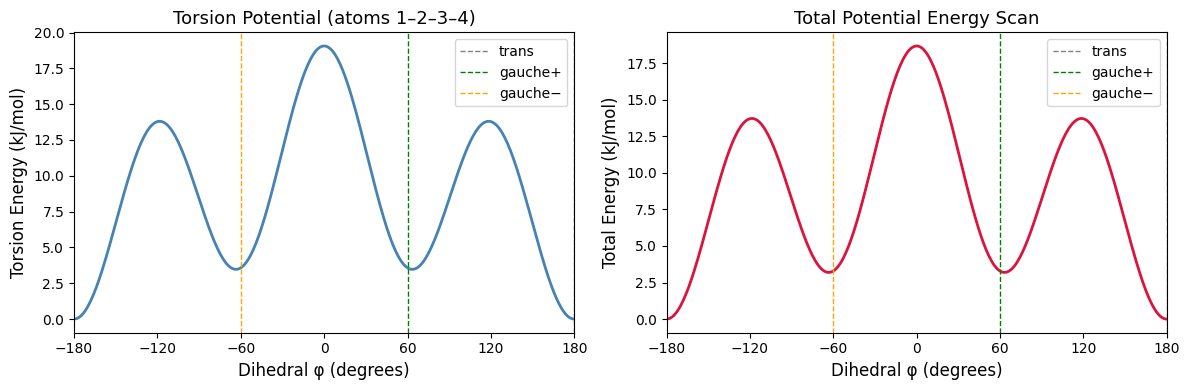


Saved: plots/torsion_energy_scan.png


In [114]:
# ─────────────────────────────────────────────────────────────────────────────
# Cell 4 — Force Field Energy Functions (TraPPE-UA)
# ─────────────────────────────────────────────────────────────────────────────


# ── Helper: dihedral angle ───────────────────────────────────────────────────-

def _dihedral_rad(p0, p1, p2, p3):
    """
    Returns dihedral angle in radians for the sequence p0-p1-p2-p3.
    Convention: trans = ±π, gauche± = ±π/3.
    Uses the atan2 formula for numerical stability.
    """
    b1 = p1 - p0
    b2 = p2 - p1
    b3 = p3 - p2
    n1 = np.cross(b1, b2)
    n2 = np.cross(b2, b3)
    b2_norm = b2 / np.linalg.norm(b2)
    m1 = np.cross(n1, b2_norm)
    x  = np.dot(n1, n2)
    y  = np.dot(m1, n2)
    return np.arctan2(y, x)


def _dihedral_rad_batch(p0, p1, p2, p3):
    """Vectorized dihedral angles for batched coordinates."""
    b1 = p1 - p0
    b2 = p2 - p1
    b3 = p3 - p2
    n1 = np.cross(b1, b2)
    n2 = np.cross(b2, b3)
    b2_norm = b2 / np.linalg.norm(b2, axis=2, keepdims=True)
    m1 = np.cross(n1, b2_norm)
    x  = np.sum(n1 * n2, axis=2)
    y  = np.sum(m1 * n2, axis=2)
    return np.arctan2(y, x)

# ── Helper: Lorentz-Berthelot mixing rules ─────────────────────────────────--

def _lj_mixed(type_i, type_j):
    """
    Returns (eps_ij, sig_ij) using Lorentz-Berthelot rules:
      sigma_ij   = (sigma_i + sigma_j) / 2
      epsilon_ij = sqrt(epsilon_i * epsilon_j)
    """
    ei = LJ[type_i]['eps'];  si = LJ[type_i]['sig']
    ej = LJ[type_j]['eps'];  sj = LJ[type_j]['sig']
    return np.sqrt(ei * ej), 0.5 * (si + sj)

# ── Energy components (vectorized core) ─────────────────────────────────------

def _bond_energy_batch(pos):
    r_vec = pos[:, BOND_IDX[:, 1]] - pos[:, BOND_IDX[:, 0]]
    r     = np.linalg.norm(r_vec, axis=2)
    return 0.5 * K_BOND * np.sum((r - R0_CC)**2, axis=1)


def _angle_energy_batch(pos):
    i, j, k = ANGLE_IDX[:, 0], ANGLE_IDX[:, 1], ANGLE_IDX[:, 2]
    v1 = pos[:, i] - pos[:, j]
    v2 = pos[:, k] - pos[:, j]
    cos_theta = np.sum(v1 * v2, axis=2) / (
        np.linalg.norm(v1, axis=2) * np.linalg.norm(v2, axis=2)
    )
    cos_theta = np.clip(cos_theta, -1.0, 1.0)
    theta = np.arccos(cos_theta)
    return 0.5 * K_ANGLE * np.sum((theta - THETA0)**2, axis=1)


def _torsion_energy_batch(pos):
    i, j, k, l = (TORSION_IDX[:, 0], TORSION_IDX[:, 1],
                  TORSION_IDX[:, 2], TORSION_IDX[:, 3])
    phi = _dihedral_rad_batch(pos[:, i], pos[:, j], pos[:, k], pos[:, l])
    term = (C0_TORS
            + C1_TORS * (1 + np.cos(phi))
            + C2_TORS * (1 - np.cos(2 * phi))
            + C3_TORS * (1 + np.cos(3 * phi)))
    return np.sum(term, axis=1)


def _lj_energy_batch(pos):
    i, j = NONBONDED_IDX[:, 0], NONBONDED_IDX[:, 1]
    eps_ij = np.sqrt(ATOM_EPS[i] * ATOM_EPS[j])
    sig_ij = 0.5 * (ATOM_SIG[i] + ATOM_SIG[j])
    r_vec = pos[:, j] - pos[:, i]
    r = np.linalg.norm(r_vec, axis=2)
    sr6 = (sig_ij / r)**6
    return np.sum(4.0 * eps_ij * (sr6**2 - sr6), axis=1)

# ── Energy components (public API) ─────────────────────────────────────────---

def bond_energy(positions):
    """
    Harmonic bond stretching:
      V_bond = (K_BOND / 2) * (r_ij - R0)^2
    Summed over all 4 bonds: (0-1), (1-2), (2-3), (3-4)
    Units: kJ/mol
    """
    pos = np.asarray(positions)
    if pos.ndim == 2:
        return float(_bond_energy_batch(pos[None, ...])[0])
    return _bond_energy_batch(pos)


def angle_energy(positions):
    """
    Harmonic angle bending:
      V_angle = (K_ANGLE / 2) * (theta_ijk - THETA0)^2
    Summed over all 3 angles: (0-1-2), (1-2-3), (2-3-4)
    Units: kJ/mol
    """
    pos = np.asarray(positions)
    if pos.ndim == 2:
        return float(_angle_energy_batch(pos[None, ...])[0])
    return _angle_energy_batch(pos)


def torsion_energy(positions):
    """
    Fourier torsion potential (IUPAC dihedral):
        V(phi) = C0 + C1(1 + cos(phi)) + C2(1 - cos(2phi)) + C3(1 + cos(3phi))

    Summed over both backbone dihedrals: (0-1-2-3) and (1-2-3-4).
    Units: kJ/mol
    """
    pos = np.asarray(positions)
    total = 0.0
    for (i, j, k, l) in TORSIONS:
        phi = _dihedral_rad(pos[i], pos[j], pos[k], pos[l])
        total += (C0_TORS
                  + C1_TORS * (1 + np.cos(phi))
                  + C2_TORS * (1 - np.cos(2 * phi))
                  + C3_TORS * (1 + np.cos(3 * phi)))
    return total


def lj_energy(positions):
    """
    Lennard-Jones non-bonded interactions:
      V_LJ = 4 * eps_ij * [ (sig_ij/r)^12 - (sig_ij/r)^6 ]

    Pairs included (TraPPE-UA convention for linear alkanes):
      - 1-4 pairs  : (0,3), (1,4)   → full LJ (no scaling)
      - 1-5 pair   : (0,4)          → full LJ

    Excluded pairs (1-2 and 1-3): no interaction.
    Mixing rules: Lorentz-Berthelot.
    Units: kJ/mol
    """
    pos = np.asarray(positions)
    if pos.ndim == 2:
        return float(_lj_energy_batch(pos[None, ...])[0])
    return _lj_energy_batch(pos)


def total_energy(positions):
    """
    Full TraPPE-UA potential energy of n-pentane:
      E_total = E_bond + E_angle + E_torsion + E_LJ
    Units: kJ/mol
    """
    pos = np.asarray(positions)
    if pos.ndim == 2:
        return float(_bond_energy_batch(pos[None, ...])[0]
                     + _angle_energy_batch(pos[None, ...])[0]
                     + _torsion_energy_batch(pos[None, ...])[0]
                     + _lj_energy_batch(pos[None, ...])[0])
    return (_bond_energy_batch(pos)
            + _angle_energy_batch(pos)
            + _torsion_energy_batch(pos)
            + _lj_energy_batch(pos))


def total_energy_batch(positions_batch):
    """Vectorized total energy for positions_batch with shape (N, 5, 3)."""
    pos = np.asarray(positions_batch)
    return (_bond_energy_batch(pos)
            + _angle_energy_batch(pos)
            + _torsion_energy_batch(pos)
            + _lj_energy_batch(pos))


# ── Sanity checks ─────────────────────────────────────────────────────────----

if __name__ == "__main__" or True:

    pos_trans  = build_pentane(phi1=180.0, phi2=180.0)
    pos_gauche = build_pentane(phi1= 60.0, phi2=180.0)
    pos_eclip  = build_pentane(phi1=  0.0, phi2=180.0)


    for label, pos in [("Trans(180°)", pos_trans),
                        ("Gauche+(60°)", pos_gauche),
                        ("Eclipsed(0°)", pos_eclip)]:
        Eb  = bond_energy(pos)
        Ea  = angle_energy(pos)
        Et  = torsion_energy(pos)
        Elj = lj_energy(pos)
        Etot = total_energy(pos)
        print(f"\nConformation: {label}")
        print(f"  Bond energy   : {Eb:10.4f} kJ/mol")
        print(f"  Angle energy  : {Ea:10.4f} kJ/mol")
        print(f"  Torsion energy: {Et:10.4f} kJ/mol")
        print(f"  LJ energy     : {Elj:10.4f} kJ/mol")
        print(f"  Total energy  : {Etot:10.4f} kJ/mol")

    # ── Plot torsion potential scan ─────────────────────────────────────---
    phi_vals = np.linspace(-180, 180, 361)
    E_tors_scan = []
    E_total_scan = []

    for phi in phi_vals:
        pos = build_pentane(phi1=phi, phi2=180.0)
        E_tors_scan.append(torsion_energy(pos))
        E_total_scan.append(total_energy(pos))

    # Shift so minimum = 0
    E_tors_arr  = np.array(E_tors_scan)  - min(E_tors_scan)
    E_total_arr = np.array(E_total_scan) - min(E_total_scan)

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].plot(phi_vals, E_tors_arr, color='steelblue', lw=2)
    axes[0].set_xlabel("Dihedral φ (degrees)", fontsize=12)
    axes[0].set_ylabel("Torsion Energy (kJ/mol)", fontsize=12)
    axes[0].set_title("Torsion Potential (atoms 1–2–3–4)", fontsize=13)
    axes[0].axvline( 180, color='gray', ls='--', lw=1, label='trans')
    axes[0].axvline(  60, color='green', ls='--', lw=1, label='gauche+')
    axes[0].axvline( -60, color='orange', ls='--', lw=1, label='gauche−')
    axes[0].legend(fontsize=10)
    axes[0].set_xlim(-180, 180)
    axes[0].set_xticks(np.arange(-180, 181, 60))

    axes[1].plot(phi_vals, E_total_arr, color='crimson', lw=2)
    axes[1].set_xlabel("Dihedral φ (degrees)", fontsize=12)
    axes[1].set_ylabel("Total Energy (kJ/mol)", fontsize=12)
    axes[1].set_title("Total Potential Energy Scan", fontsize=13)
    axes[1].axvline( 180, color='gray', ls='--', lw=1, label='trans')
    axes[1].axvline(  60, color='green', ls='--', lw=1, label='gauche+')
    axes[1].axvline( -60, color='orange', ls='--', lw=1, label='gauche−')
    axes[1].legend(fontsize=10)
    axes[1].set_xlim(-180, 180)
    axes[1].set_xticks(np.arange(-180, 181, 60))

    plt.tight_layout()
    plt.savefig("plots/torsion_energy_scan.png", dpi=150)
    plt.show()
    print("\nSaved: plots/torsion_energy_scan.png")

### Dihedral utilities
Adds dihedral calculators, validates them on test conformations, and plots round-trip accuracy.

In [115]:
# ─────────────────────────────────────────────────────────────────────────────
# Cell 5 — Dihedral Calculation Utility
# ─────────────────────────────────────────────────────────────────────────────

def compute_dihedral(p0, p1, p2, p3):
    """
    Computes the dihedral (torsion) angle for the atom sequence p0-p1-p2-p3.

    Uses the atan2 formula via normal vectors for full [-180, 180] range
    and numerical stability near 0° and 180°.

    Convention  (IUPAC / standard MD):
        trans  =  180°  (or ±180°)
        gauche+ =  +60°
        gauche− =  -60°
        eclipsed =   0°

    Parameters
    ----------
    p0, p1, p2, p3 : array-like, shape (3,)
        Cartesian coordinates in any consistent unit (Å, nm, …)

    Returns
    -------
    angle_deg : float
        Dihedral angle in degrees, in the range (-180, 180].
    """
    p0 = np.asarray(p0, dtype=float)
    p1 = np.asarray(p1, dtype=float)
    p2 = np.asarray(p2, dtype=float)
    p3 = np.asarray(p3, dtype=float)

    # Bond vectors
    b1 = p1 - p0   # vector along bond 0→1
    b2 = p2 - p1   # vector along bond 1→2  (the central bond)
    b3 = p3 - p2   # vector along bond 2→3

    # Normal vectors to the two planes
    n1 = np.cross(b1, b2)   # normal to plane defined by b1, b2
    n2 = np.cross(b2, b3)   # normal to plane defined by b2, b3

    # Unit vector along the central bond
    b2_hat = b2 / np.linalg.norm(b2)

    # m1 completes a right-handed frame: (n1, m1, b2_hat)
    # It lies in the first plane but perpendicular to b2
    m1 = np.cross(n1, b2_hat)

    # atan2 gives the signed angle in the full [-π, π] range
    # x = cos(phi), y = sin(phi)
    x = np.dot(n1, n2)
    y = np.dot(m1, n2)

    angle_rad = np.arctan2(y, x)
    angle_deg = np.degrees(angle_rad)

    return angle_deg


def compute_all_dihedrals(positions):
    """
    Computes both backbone dihedrals of n-pentane.

    Returns
    -------
    phi_1234 : float
        Dihedral C1-C2-C3-C4 (atoms 1,2,3,4) — the PROJECT dihedral of interest.
    phi_0123 : float
        Dihedral C0-C1-C2-C3 (atoms 0,1,2,3) — the second backbone dihedral.
    """
    phi_1234 = compute_dihedral(positions[1], positions[2],
                                positions[3], positions[4])
    phi_0123 = compute_dihedral(positions[0], positions[1],
                                positions[2], positions[3])
    return phi_1234, phi_0123


# ── Sanity checks ─────────────────────────────────────────────────────────────

if __name__ == "__main__" or True:

    print("=" * 50)
    print("Dihedral sanity checks")
    print("=" * 50)

    # ── Test all canonical conformations ──────────────────────────────────
    test_cases = [
        ( 180.0,  180.0, "all-trans"),
        (  60.0,  180.0, "gauche+ / trans"),
        ( -60.0,  180.0, "gauche− / trans"),
        (  60.0,   60.0, "gauche+ / gauche+"),
        (   0.0,  180.0, "eclipsed / trans"),
        ( 120.0,  180.0, "barrier region"),
    ]

    print(f"\n{'Config':<26} {'phi1 set':>9} {'phi1 calc':>10} {'phi2 set':>9} {'phi2 calc':>10} {'match':>6}")
    print("-" * 75)

    all_pass = True
    for phi1_set, phi2_set, label in test_cases:
        pos = build_pentane(phi1=phi1_set, phi2=phi2_set)
        phi1_calc, phi2_calc = compute_all_dihedrals(pos)
        # Allow 0.1° tolerance for floating point
        match1 = abs(phi1_calc - phi1_set) < 0.1
        match2 = abs(phi2_calc - phi2_set) < 0.1
        ok = "✓" if (match1 and match2) else "✗"
        if not (match1 and match2):
            all_pass = False
        print(f"{label:<26} {phi1_set:>9.1f} {phi1_calc:>10.3f} "
              f"{phi2_set:>9.1f} {phi2_calc:>10.3f} {ok:>6}")

    print("-" * 75)
    print(f"All tests passed: {all_pass}")

Dihedral sanity checks

Config                      phi1 set  phi1 calc  phi2 set  phi2 calc  match
---------------------------------------------------------------------------
all-trans                      180.0    180.000     180.0    180.000      ✓
gauche+ / trans                 60.0     60.000     180.0    180.000      ✓
gauche− / trans                -60.0    -60.000     180.0    180.000      ✓
gauche+ / gauche+               60.0     60.000      60.0     60.000      ✓
eclipsed / trans                 0.0      0.000     180.0    180.000      ✓
barrier region                 120.0    120.000     180.0    180.000      ✓
---------------------------------------------------------------------------
All tests passed: True


### Monte Carlo sampling (NVT)
Runs Metropolis MC at 120 K and 250 K, records dihedrals and energies, and plots time series and histograms.


Running MC at 120 K ...
  Acceptance rate : 14.2%
  Final max_disp  : 0.0100 Å
  Dihedral range  : [-180.0°, 180.0°]
  Barrier crossings (|Δφ|>90°): 312

Running MC at 250 K ...
  Acceptance rate : 21.7%
  Final max_disp  : 0.0100 Å
  Dihedral range  : [-180.0°, 180.0°]
  Barrier crossings (|Δφ|>90°): 210


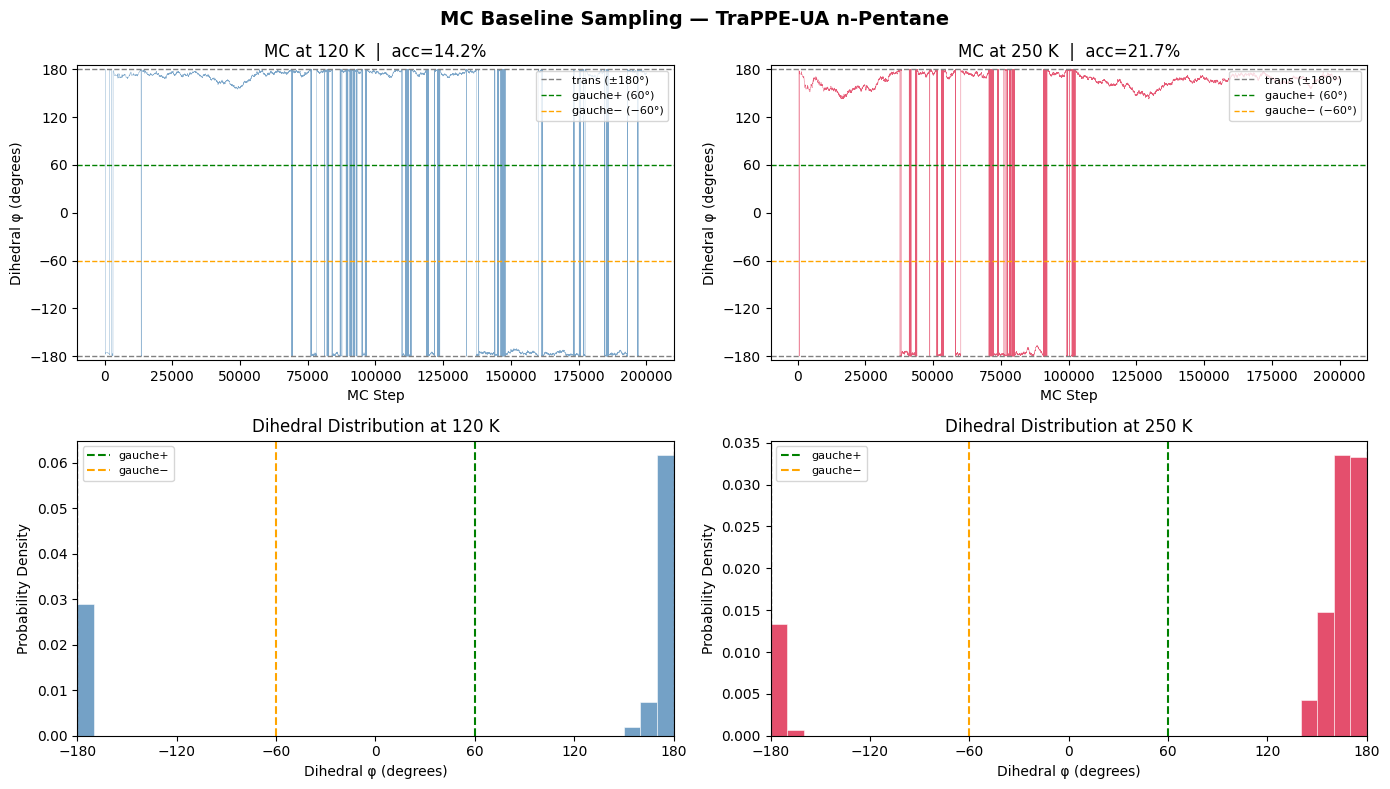

Saved: plots/mc_baseline.png


In [116]:
# ─────────────────────────────────────────────────────────────────────────────
# Cell 6 — Task 2a: Monte Carlo Simulation (NVT, Metropolis)
# ─────────────────────────────────────────────────────────────────────────────

def run_MC(positions, T, n_steps=200000, max_disp=0.1,
           adaptive=True, target_acceptance=0.4, adapt_interval=500):
    """
    NVT Monte Carlo simulation of n-pentane using the Metropolis criterion.

    Move set: random Cartesian displacement of one randomly chosen atom.

    Parameters
    ----------
    positions        : np.ndarray, shape (5,3)  — initial configuration (Å)
    T                : float                    — temperature (K)
    n_steps          : int                      — number of MC steps
    max_disp         : float                    — initial max displacement (Å)
    adaptive         : bool                     — adapt max_disp to hit target
    target_acceptance: float                    — target acceptance ratio
    adapt_interval   : int                      — steps between adaptations

    Returns
    -------
    dihedrals   : np.ndarray, shape (n_steps,)  — dihedral C1-C2-C3-C4 (degrees)
    energies    : np.ndarray, shape (n_steps,)  — total energy at each step (kJ/mol)
    acceptance  : float                         — overall acceptance ratio
    max_disp    : float                         — final adapted displacement
    """
    positions = positions.copy()           # never mutate the caller's array
    beta      = 1.0 / (kB_kJ * T)         # 1/(kB*T) in mol/kJ

    E = total_energy(positions)

    dihedrals  = np.zeros(n_steps)
    energies   = np.zeros(n_steps)

    accepted       = 0
    accepted_window = 0   # accepted moves in the current adapt window

    for step in range(n_steps):

        # ── Propose move ──────────────────────────────────────────────────
        atom  = np.random.randint(0, 5)
        delta = (np.random.rand(3) * 2.0 - 1.0) * max_disp  # uniform in [-d, d]^3

        trial          = positions.copy()
        trial[atom]   += delta

        # ── Evaluate energy change ────────────────────────────────────────
        E_trial = total_energy(trial)
        dE      = E_trial - E

        # ── Metropolis acceptance ─────────────────────────────────────────
        if dE <= 0.0 or np.random.rand() < np.exp(-beta * dE):
            positions = trial
            E         = E_trial
            accepted         += 1
            accepted_window  += 1

        # ── Record observables ────────────────────────────────────────────
        # BUG FIX: original code used positions[0:4] → gives only 4 atoms,
        # so compute_dihedral received C0,C1,C2,C3 (the WRONG dihedral).
        # The project dihedral is C1-C2-C3-C4 (atoms 1,2,3,4).
        dihedrals[step] = compute_dihedral(positions[1], positions[2],
                                           positions[3], positions[4])
        energies[step]  = E

        # ── Adaptive step size ────────────────────────────────────────────
        if adaptive and (step + 1) % adapt_interval == 0:
            window_acc = accepted_window / adapt_interval
            if window_acc > target_acceptance:
                max_disp *= 1.05   # too many accepted → increase step
            else:
                max_disp *= 0.95   # too few accepted  → decrease step
            max_disp         = np.clip(max_disp, 0.01, 0.5)
            accepted_window  = 0

    acceptance = accepted / n_steps
    return dihedrals, energies, acceptance, max_disp


def run_MC_both_temps(n_steps=200000):
    """
    Runs MC at 120 K and 250 K from the same all-trans starting config.
    Returns a dict with results for both temperatures.
    """
    results = {}
    pos0 = build_pentane(phi1=180.0, phi2=180.0)

    for T in [120, 250]:
        print(f"\nRunning MC at {T} K ...")
        dihedrals, energies, acc, final_disp = run_MC(
            positions  = pos0.copy(),
            T          = T,
            n_steps    = n_steps,
            max_disp   = 0.1,
            adaptive   = True,
        )
        results[T] = {
            'dihedrals' : dihedrals,
            'energies'  : energies,
            'acceptance': acc,
            'final_disp': final_disp,
        }
        print(f"  Acceptance rate : {acc*100:.1f}%")
        print(f"  Final max_disp  : {final_disp:.4f} Å")
        print(f"  Dihedral range  : [{dihedrals.min():.1f}°, {dihedrals.max():.1f}°]")
        # Count barrier crossings: |Δφ| > 90° between consecutive steps
        crossings = np.sum(np.abs(np.diff(dihedrals)) > 90)
        print(f"  Barrier crossings (|Δφ|>90°): {crossings}")

    return results


# ── Run simulations ───────────────────────────────────────────────────────────
mc_results = run_MC_both_temps(n_steps=200000)


# ── Plotting ──────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
fig.suptitle("MC Baseline Sampling — TraPPE-UA n-Pentane", fontsize=14, fontweight='bold')

COLORS = {120: 'steelblue', 250: 'crimson'}
steps  = np.arange(200000)

for col, T in enumerate([120, 250]):
    d   = mc_results[T]['dihedrals']
    acc = mc_results[T]['acceptance']

    # ── Row 0: dihedral time series ───────────────────────────────────────
    ax = axes[0, col]
    ax.plot(steps, d, lw=0.3, alpha=0.7, color=COLORS[T])
    ax.axhline( 180, color='gray',   ls='--', lw=1, label='trans (±180°)')
    ax.axhline(-180, color='gray',   ls='--', lw=1)
    ax.axhline(  60, color='green',  ls='--', lw=1, label='gauche+ (60°)')
    ax.axhline( -60, color='orange', ls='--', lw=1, label='gauche− (−60°)')
    ax.set_title(f"MC at {T} K  |  acc={acc*100:.1f}%", fontsize=12)
    ax.set_xlabel("MC Step", fontsize=10)
    ax.set_ylabel("Dihedral φ (degrees)", fontsize=10)
    ax.set_ylim(-185, 185)
    ax.set_yticks([-180, -120, -60, 0, 60, 120, 180])
    ax.legend(fontsize=8, loc='upper right')

    # ── Row 1: dihedral histogram (36 bins) ───────────────────────────────
    ax = axes[1, col]
    counts, bin_edges, _ = ax.hist(
        d, bins=36, range=(-180, 180),
        color=COLORS[T], alpha=0.75, edgecolor='white', lw=0.5,
        density=True
    )
    ax.axvline( 180, color='gray',   ls='--', lw=1)
    ax.axvline(-180, color='gray',   ls='--', lw=1)
    ax.axvline(  60, color='green',  ls='--', lw=1.5, label='gauche+')
    ax.axvline( -60, color='orange', ls='--', lw=1.5, label='gauche−')
    ax.set_title(f"Dihedral Distribution at {T} K", fontsize=12)
    ax.set_xlabel("Dihedral φ (degrees)", fontsize=10)
    ax.set_ylabel("Probability Density", fontsize=10)
    ax.set_xlim(-180, 180)
    ax.set_xticks(np.arange(-180, 181, 60))
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig("plots/mc_baseline.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved: plots/mc_baseline.png")

### Molecular dynamics sampling (NVT)
Implements velocity Verlet MD with velocity rescaling, runs both temperatures, and plots dihedrals, histograms, and temperature traces.

Compiling Numba kernels (one-time, ~2 s)...
Done. Running full simulations...

Running MD at 120 K  (200000 steps, dt=0.002 ps) ...
  Time            : 0.5 s
  Mean T          : 119.87 K  (target 120 K)
  Std  T          : 84.63 K
  Mean PE         : 1.393 kJ/mol
  Dihedral range  : [-180.0°, 180.0°]
  Barrier crossings (|Δφ|>90°): 438

Running MD at 250 K  (200000 steps, dt=0.002 ps) ...
  Time            : 0.5 s
  Mean T          : 250.18 K  (target 250 K)
  Std  T          : 145.46 K
  Mean PE         : -0.074 kJ/mol
  Dihedral range  : [-180.0°, 180.0°]
  Barrier crossings (|Δφ|>90°): 904



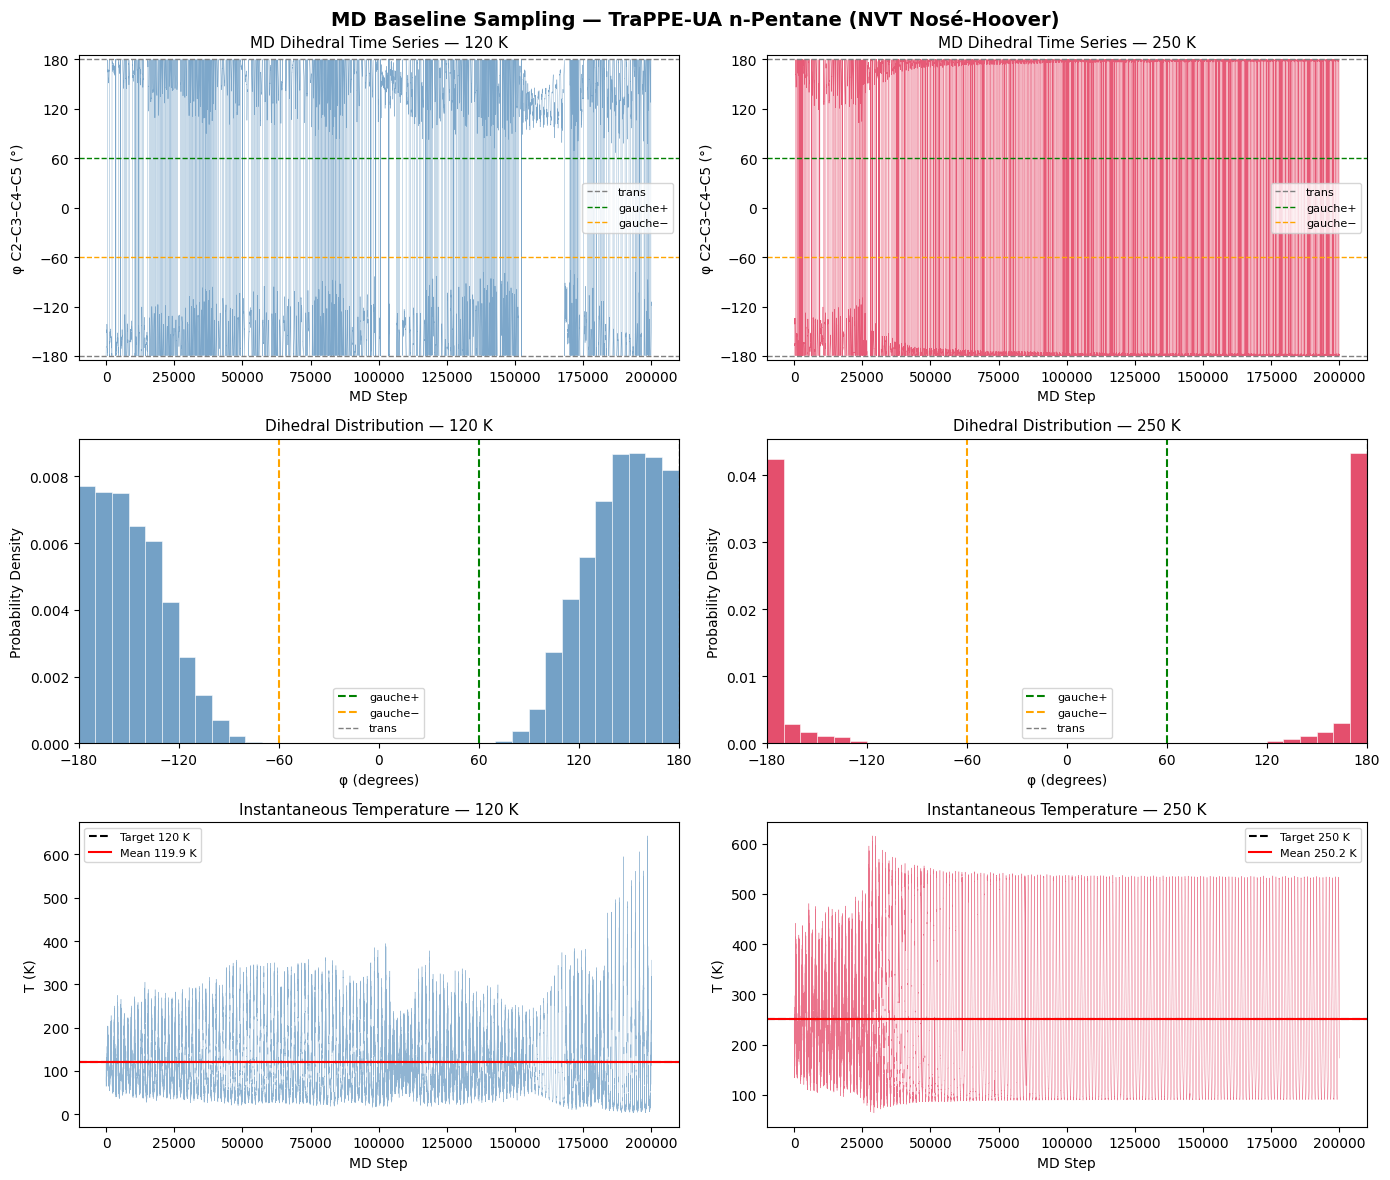

Saved: plots/md_baseline.png


In [117]:
# ─────────────────────────────────────────────────────────────────────────────
# Cell 7 — Task 2b: NVT MD (Velocity Verlet + Nosé-Hoover) — FAST VERSION
# ─────────────────────────────────────────────────────────────────────────────
from numba import njit

UNIT_FACTOR = 100.0
MASSES      = np.array([15.035, 14.027, 14.027, 14.027, 15.035])
kB_kJ       = 8.314e-3   # kJ/(mol·K)
tau_T       = 0.5        # ps

# ── Pre-compute constants once (pass into JIT functions) ──────────────────────
_LJ_EPS  = np.array([0.8134, 0.3824])  # kJ/mol — CH3-CH3, CH3-CH2 mix, CH2-CH2
_LJ_SIG  = np.array([3.750, 3.850, 3.950])  # Å
# Pair indices with LJ (1-4 and 1-5 only)
_LJ_PAIRS  = np.array([[0,3],[0,4],[1,4]], dtype=np.int64)
# eps and sig for each pair
_eps_pair  = np.array([
    4 * np.sqrt(98.0*46.0) * kB_kJ,   # CH3-CH2  (0-3)
    4 * 98.0 * kB_kJ,                   # CH3-CH3  (0-4)
    4 * np.sqrt(98.0*46.0) * kB_kJ,   # CH3-CH2  (1-4)
])
_sig_pair  = np.array([
    (3.75+3.95)/2,   # CH3-CH2
    3.75,             # CH3-CH3
    (3.75+3.95)/2,   # CH3-CH2
])
# Torsion coefficients [kJ/mol]
_c1 = 355.03 * kB_kJ
_c2 = -68.19 * kB_kJ
_c3 = 791.32 * kB_kJ
# Bond / angle params
_k_bond  = 452900.0 * kB_kJ   # kJ/mol/Å²
_r0      = 1.54                 # Å
_k_angle = 62500.0  * kB_kJ   # kJ/mol/rad²
_theta0  = np.deg2rad(114.0)


@njit(cache=True)
def _forces_and_energy(pos, eps_pair, sig_pair, lj_pairs,
                        k_bond, r0, k_angle, theta0, c1, c2, c3):
    """
    Compute analytical forces and total energy in one pass.
    pos: (5,3) float64, Å
    Returns: forces (5,3) kJ/mol/Å,  U_total kJ/mol
    """
    F = np.zeros((5, 3))
    U = 0.0

    # ── Bond stretching ───────────────────────────────────────────────────────
    for b in range(4):
        rij = pos[b+1] - pos[b]
        r   = np.sqrt(rij[0]**2 + rij[1]**2 + rij[2]**2)
        dr  = r - r0
        U  += 0.5 * k_bond * dr**2
        dU  = k_bond * dr / r           # scalar gradient magnitude
        for d in range(3):
            F[b,   d] += dU * rij[d]    # force on b   (toward b+1)
            F[b+1, d] -= dU * rij[d]    # force on b+1 (reaction)

    # ── Angle bending ─────────────────────────────────────────────────────────
    for a in range(3):
        # atoms a, a+1, a+2
        rji = pos[a]   - pos[a+1]
        rjk = pos[a+2] - pos[a+1]
        nji = np.sqrt(rji[0]**2 + rji[1]**2 + rji[2]**2)
        njk = np.sqrt(rjk[0]**2 + rjk[1]**2 + rjk[2]**2)
        cos_t = (rji[0]*rjk[0] + rji[1]*rjk[1] + rji[2]*rjk[2]) / (nji*njk)
        cos_t = max(-1.0, min(1.0, cos_t))
        theta = np.arccos(cos_t)
        dtheta = theta - theta0
        U += 0.5 * k_angle * dtheta**2
        # gradient of arccos
        sin_t = np.sqrt(max(1e-10, 1.0 - cos_t**2))
        dU_dt = k_angle * dtheta          # dU/dtheta
        for d in range(3):
            gi = -(rjk[d]/(nji*njk) - cos_t*rji[d]/nji**2) / sin_t
            gk = -(rji[d]/(nji*njk) - cos_t*rjk[d]/njk**2) / sin_t
            F[a,   d] -= dU_dt * gi
            F[a+2, d] -= dU_dt * gk
            F[a+1, d] += dU_dt * (gi + gk)

    # ── Torsion (C1-C2-C3-C4 dihedral, atoms 0-1-2-3) ───────────────────────
    b0 = pos[1] - pos[0]
    b1 = pos[2] - pos[1]
    b2 = pos[3] - pos[2]

    # Normal vectors
    n1 = np.array([b0[1]*b1[2]-b0[2]*b1[1],
                   b0[2]*b1[0]-b0[0]*b1[2],
                   b0[0]*b1[1]-b0[1]*b1[0]])
    n2 = np.array([b1[1]*b2[2]-b1[2]*b2[1],
                   b1[2]*b2[0]-b1[0]*b2[2],
                   b1[0]*b2[1]-b1[1]*b2[0]])
    n1n = np.sqrt(n1[0]**2+n1[1]**2+n1[2]**2)
    n2n = np.sqrt(n2[0]**2+n2[1]**2+n2[2]**2)

    if n1n > 1e-10 and n2n > 1e-10:
        n1u = n1 / n1n
        n2u = n2 / n2n
        b1u = b1 / np.sqrt(b1[0]**2+b1[1]**2+b1[2]**2)

        cos_p = n1u[0]*n2u[0]+n1u[1]*n2u[1]+n1u[2]*n2u[2]
        sin_p = (n1u[1]*b1u[2]-n1u[2]*b1u[1])*n2u[0] + \
                (n1u[2]*b1u[0]-n1u[0]*b1u[2])*n2u[1] + \
                (n1u[0]*b1u[1]-n1u[1]*b1u[0])*n2u[2]
        phi   = np.arctan2(sin_p, cos_p)

        U += c1*(1+np.cos(phi)) + c2*(1-np.cos(2*phi)) + c3*(1+np.cos(3*phi))

        dU_dphi = -c1*np.sin(phi) + 2*c2*np.sin(2*phi) - 3*c3*np.sin(3*phi)

        # Ryckaert-Bellemans torsion force (GROMACS-style)
        f1 = dU_dphi * n1u / n1n
        f4 = dU_dphi * n2u / n2n
        for d in range(3):
            F[0, d] -= f1[d]
            F[3, d] += f4[d]
            F[1, d] += f1[d]
            F[2, d] -= f4[d]

    # ── Lennard-Jones ─────────────────────────────────────────────────────────
    for p in range(3):
        i = lj_pairs[p, 0]
        j = lj_pairs[p, 1]
        rij = pos[j] - pos[i]
        r2  = rij[0]**2 + rij[1]**2 + rij[2]**2
        r   = np.sqrt(r2)
        eps = eps_pair[p]
        sig = sig_pair[p]
        sr6  = (sig/r)**6
        sr12 = sr6**2
        U   += eps * (sr12 - sr6)
        dU   = eps * (-12*sr12 + 6*sr6) / r2
        for d in range(3):
            F[i, d] += dU * rij[d]
            F[j, d] -= dU * rij[d]

    return F, U


@njit(cache=True)
def _md_loop(pos, vel, masses, eps_pair, sig_pair, lj_pairs,
             k_bond, r0, k_angle, theta0, c1, c2, c3,
             T, n_steps, dt, tau_T, kB_kJ, UNIT_FACTOR):

    N_dof = 12
    Q     = N_dof * kB_kJ * T * tau_T**2
    xi    = 0.0

    dihedrals = np.zeros(n_steps)
    energies  = np.zeros(n_steps)
    temps     = np.zeros(n_steps)

    forces, _ = _forces_and_energy(pos, eps_pair, sig_pair, lj_pairs,
                                    k_bond, r0, k_angle, theta0, c1, c2, c3)

    for step in range(n_steps):

        # 1. NH half-kick on xi
        KE  = 0.5 * np.sum(masses * np.sum(vel**2, axis=1)) / UNIT_FACTOR
        xi += 0.5 * dt * (2.0*KE - N_dof*kB_kJ*T) / Q

        # 2. Friction half-step (exact exponential)
        scale = np.exp(-xi * 0.5 * dt)
        vel  *= scale

        # 3. Force half-kick
        for i in range(5):
            for d in range(3):
                vel[i, d] += 0.5 * dt * forces[i, d] * UNIT_FACTOR / masses[i]

        # 4. Full position update
        pos += dt * vel

        # 5. Remove COM drift
        m_tot = np.sum(masses)
        v_com = np.zeros(3)
        for i in range(5):
            for d in range(3):
                v_com[d] += masses[i] * vel[i, d] / m_tot
        for i in range(5):
            for d in range(3):
                vel[i, d] -= v_com[d]

        # 6. Recompute forces
        forces, U = _forces_and_energy(pos, eps_pair, sig_pair, lj_pairs,
                                        k_bond, r0, k_angle, theta0, c1, c2, c3)

        # 7. Force half-kick
        for i in range(5):
            for d in range(3):
                vel[i, d] += 0.5 * dt * forces[i, d] * UNIT_FACTOR / masses[i]

        # 8. Friction half-step (exact exponential)
        scale = np.exp(-xi * 0.5 * dt)
        vel  *= scale

        # 9. NH second half-kick on xi
        KE  = 0.5 * np.sum(masses * np.sum(vel**2, axis=1)) / UNIT_FACTOR
        xi += 0.5 * dt * (2.0*KE - N_dof*kB_kJ*T) / Q

        # Record dihedral (atoms 1,2,3,4 = C2-C3-C4-C5)
        b0 = pos[2] - pos[1]
        b1 = pos[3] - pos[2]
        b2 = pos[4] - pos[3]
        n1 = np.array([b0[1]*b1[2]-b0[2]*b1[1],
                       b0[2]*b1[0]-b0[0]*b1[2],
                       b0[0]*b1[1]-b0[1]*b1[0]])
        n2 = np.array([b1[1]*b2[2]-b1[2]*b2[1],
                       b1[2]*b2[0]-b1[0]*b2[2],
                       b1[0]*b2[1]-b1[1]*b2[0]])
        n1n = np.sqrt(n1[0]**2+n1[1]**2+n1[2]**2)
        n2n = np.sqrt(n2[0]**2+n2[1]**2+n2[2]**2)
        if n1n > 1e-10 and n2n > 1e-10:
            b1u = b1 / np.sqrt(b1[0]**2+b1[1]**2+b1[2]**2)
            n1u = n1/n1n; n2u = n2/n2n
            cos_p = n1u[0]*n2u[0]+n1u[1]*n2u[1]+n1u[2]*n2u[2]
            sin_p = (n1u[1]*b1u[2]-n1u[2]*b1u[1])*n2u[0] + \
                    (n1u[2]*b1u[0]-n1u[0]*b1u[2])*n2u[1] + \
                    (n1u[0]*b1u[1]-n1u[1]*b1u[0])*n2u[2]
            dihedrals[step] = np.degrees(np.arctan2(sin_p, cos_p))
        else:
            dihedrals[step] = dihedrals[step-1]

        energies[step] = U
        temps[step]    = 2.0 * KE / (N_dof * kB_kJ)

    return dihedrals, energies, temps


def run_MD(positions, T, n_steps=200000, dt=0.002, seed=42):
    pos = positions.copy().astype(np.float64)
    rng   = np.random.default_rng(seed)
    sigma = np.sqrt(kB_kJ * T * UNIT_FACTOR / MASSES)
    vel   = rng.normal(0.0, 1.0, (5,3)) * sigma[:, None]
    v_com = np.sum(MASSES[:, None] * vel, axis=0) / MASSES.sum()
    vel  -= v_com
    KE0   = 0.5 * np.sum(MASSES[:, None] * vel**2) / UNIT_FACTOR
    T0    = 2.0 * KE0 / (12 * kB_kJ)
    if T0 > 0:
        vel *= np.sqrt(T / T0)
    vel = vel.astype(np.float64)

    ep = np.array([4*np.sqrt(98.0*46.0)*kB_kJ,
                   4*98.0*kB_kJ,
                   4*np.sqrt(98.0*46.0)*kB_kJ])
    sp = np.array([(3.75+3.95)/2, 3.75, (3.75+3.95)/2])
    lp = np.array([[0,3],[0,4],[1,4]], dtype=np.int64)

    return _md_loop(pos, vel, MASSES.astype(np.float64),
                    ep, sp, lp,
                    _k_bond, _r0, _k_angle, _theta0,
                    _c1, _c2, _c3,
                    float(T), n_steps, dt, tau_T, kB_kJ, UNIT_FACTOR)


def run_MD_both_temps(n_steps=200000):
    md_results = {}
    pos0 = build_pentane(phi1=180.0, phi2=180.0)

    # warm-up JIT compile (runs ~100 steps, takes ~2s once, then cached)
    print("Compiling Numba kernels (one-time, ~2 s)...")
    _ = run_MD(pos0.copy(), T=120, n_steps=100, seed=0)
    print("Done. Running full simulations...\n")

    for T in [120, 250]:
        import time
        t0 = time.time()
        print(f"Running MD at {T} K  ({n_steps} steps, dt=0.002 ps) ...")
        dihedrals, energies, temps = run_MD(pos0.copy(), T=T,
                                             n_steps=n_steps, dt=0.002, seed=42)
        elapsed = time.time() - t0
        md_results[T] = {'dihedrals': dihedrals,
                         'energies':  energies,
                         'temps':     temps}
        crossings = np.sum(np.abs(np.diff(dihedrals)) > 90)
        print(f"  Time            : {elapsed:.1f} s")
        print(f"  Mean T          : {temps.mean():.2f} K  (target {T} K)")
        print(f"  Std  T          : {temps.std():.2f} K")
        print(f"  Mean PE         : {energies.mean():.3f} kJ/mol")
        print(f"  Dihedral range  : [{dihedrals.min():.1f}°, {dihedrals.max():.1f}°]")
        print(f"  Barrier crossings (|Δφ|>90°): {crossings}\n")

    return md_results


md_results = run_MD_both_temps(n_steps=200000)

COLORS = {120: 'steelblue', 250: 'crimson'}
steps  = np.arange(200000)

fig, axes = plt.subplots(3, 2, figsize=(14, 12))
fig.suptitle("MD Baseline Sampling — TraPPE-UA n-Pentane (NVT Nosé-Hoover)",
             fontsize=14, fontweight='bold')

for col, T in enumerate([120, 250]):
    d = md_results[T]['dihedrals']
    e = md_results[T]['energies']
    t = md_results[T]['temps']

    # ── Row 0: Dihedral time series ──────────────────────────────────────────
    ax = axes[0, col]
    ax.plot(steps, d, lw=0.3, alpha=0.7, color=COLORS[T])
    for val, color, label in [
        ( 180, 'gray',   'trans'),
        (-180, 'gray',   ''),
        (  60, 'green',  'gauche+'),
        ( -60, 'orange', 'gauche−'),
    ]:
        ax.axhline(val, color=color, ls='--', lw=1,
                   label=label if label else None)
    ax.set_title(f"MD Dihedral Time Series — {T} K", fontsize=11)
    ax.set_xlabel("MD Step")
    ax.set_ylabel("φ C2–C3–C4–C5 (°)")
    ax.set_ylim(-185, 185)
    ax.set_yticks([-180, -120, -60, 0, 60, 120, 180])
    ax.legend(fontsize=8)

    # ── Row 1: Dihedral histogram ────────────────────────────────────────────
    ax = axes[1, col]
    ax.hist(d, bins=36, range=(-180, 180), density=True,
            color=COLORS[T], alpha=0.75, edgecolor='white', lw=0.5)
    ax.axvline( 60, color='green',  ls='--', lw=1.5, label='gauche+')
    ax.axvline(-60, color='orange', ls='--', lw=1.5, label='gauche−')
    ax.axvline(180, color='gray',   ls='--', lw=1.0, label='trans')
    ax.set_title(f"Dihedral Distribution — {T} K", fontsize=11)
    ax.set_xlabel("φ (degrees)")
    ax.set_ylabel("Probability Density")
    ax.set_xlim(-180, 180)
    ax.set_xticks(np.arange(-180, 181, 60))
    ax.legend(fontsize=8)

    # ── Row 2: Instantaneous temperature ────────────────────────────────────
    ax = axes[2, col]
    ax.plot(steps, t, lw=0.3, alpha=0.6, color=COLORS[T])
    ax.axhline(T,            color='black', ls='--', lw=1.5,
               label=f'Target {T} K')
    ax.axhline(np.mean(t),   color='red',   ls='-',  lw=1.5,
               label=f'Mean {np.mean(t):.1f} K')
    ax.set_title(f"Instantaneous Temperature — {T} K", fontsize=11)
    ax.set_xlabel("MD Step")
    ax.set_ylabel("T (K)")
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig("plots/md_baseline.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved: plots/md_baseline.png")

### MC vs MD comparison
Plots MC and MD side by side, summarizes crossings and conformations, and produces comparison figures.

Using precomputed MC/MD results for comparison plots.

────────────────────────────────────────────────────────────────────────
Method     T(K)     Acc%  Crossings   Trans%     G+%     G-%
────────────────────────────────────────────────────────────────────────


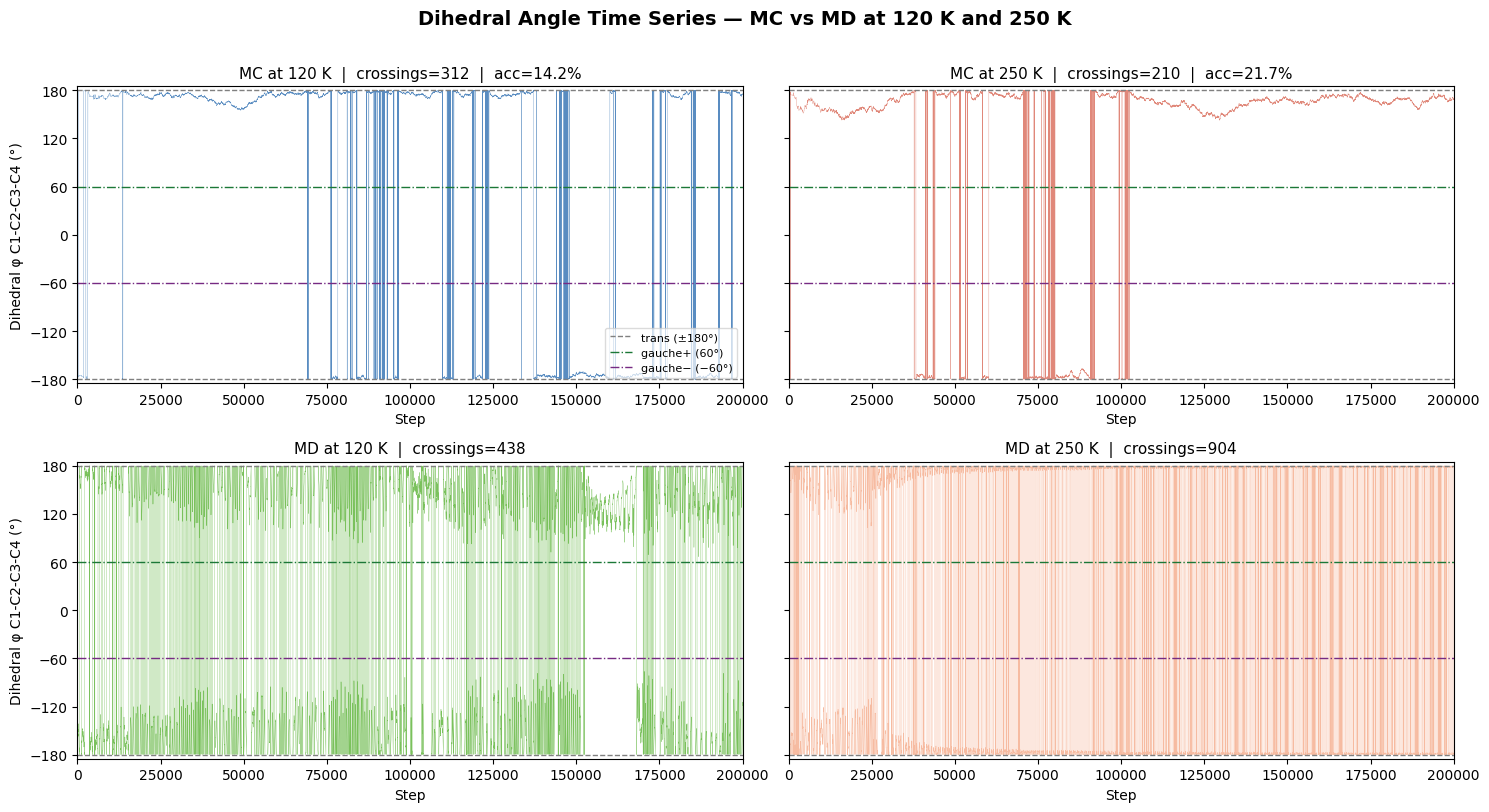

Saved: comparison_timeseries.png


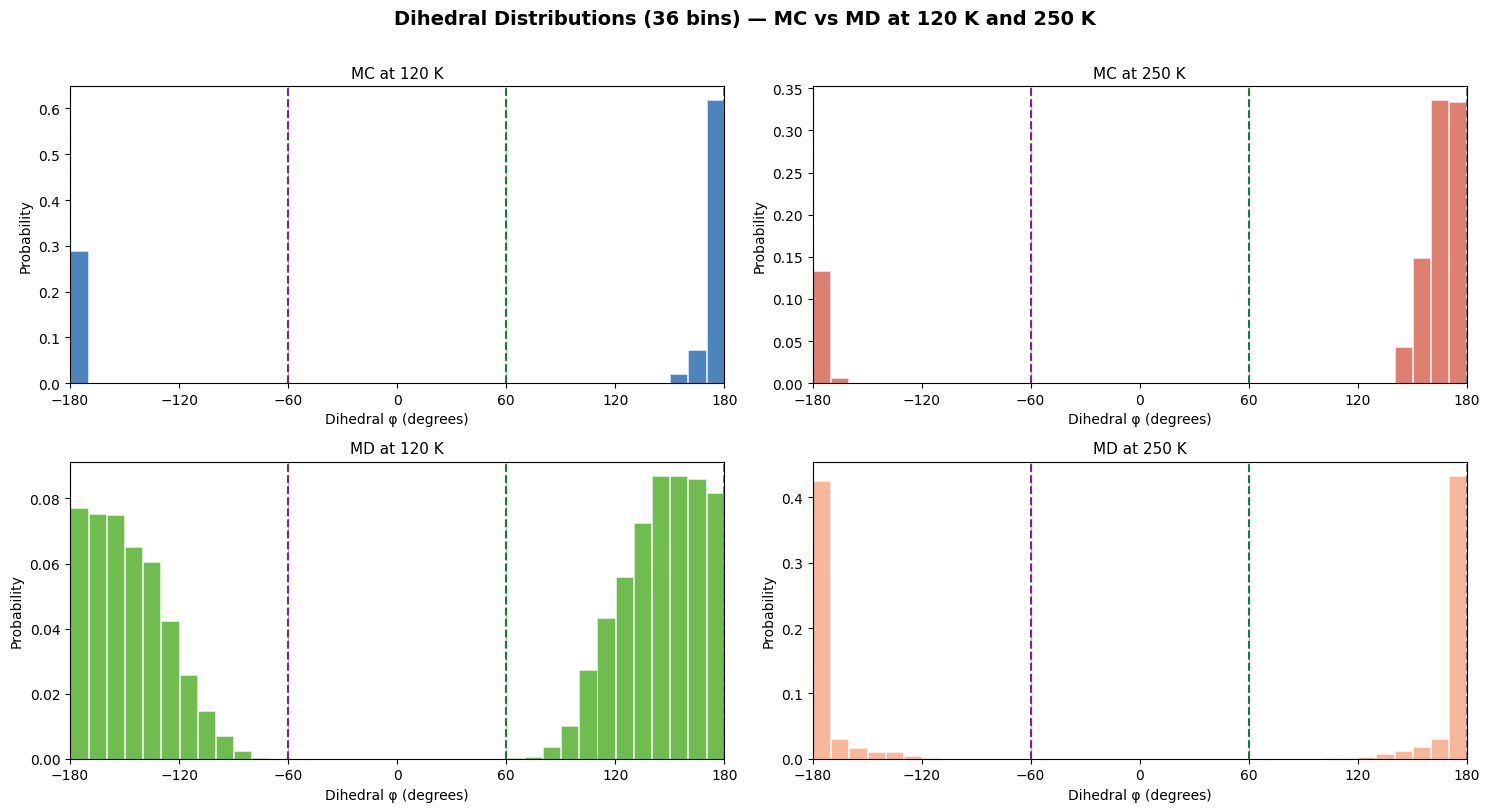

Saved: plots/comparison_histograms.png


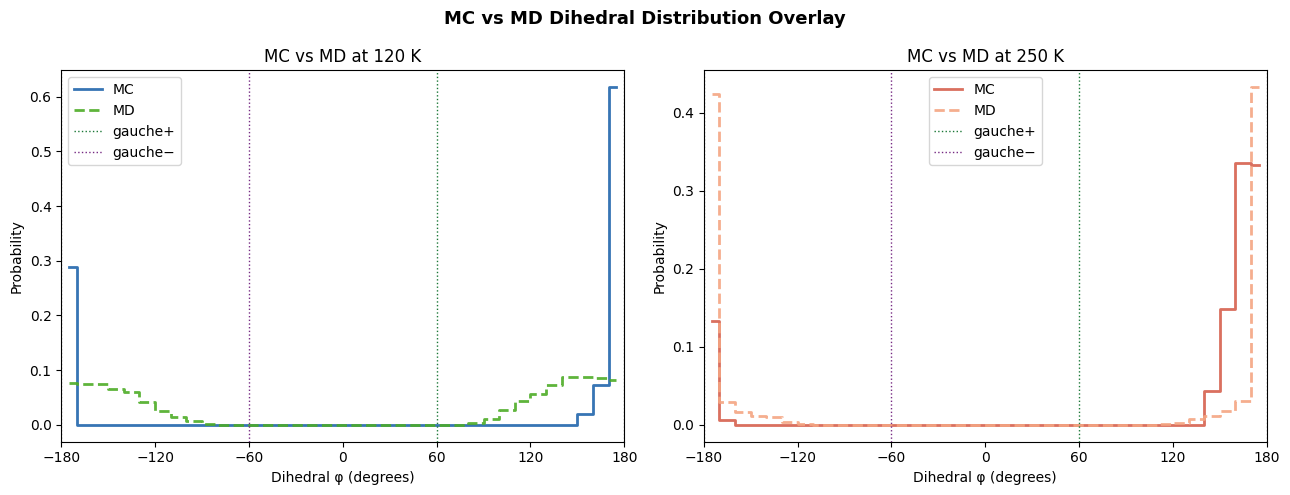

Saved: plots/mc_vs_md_overlay.png


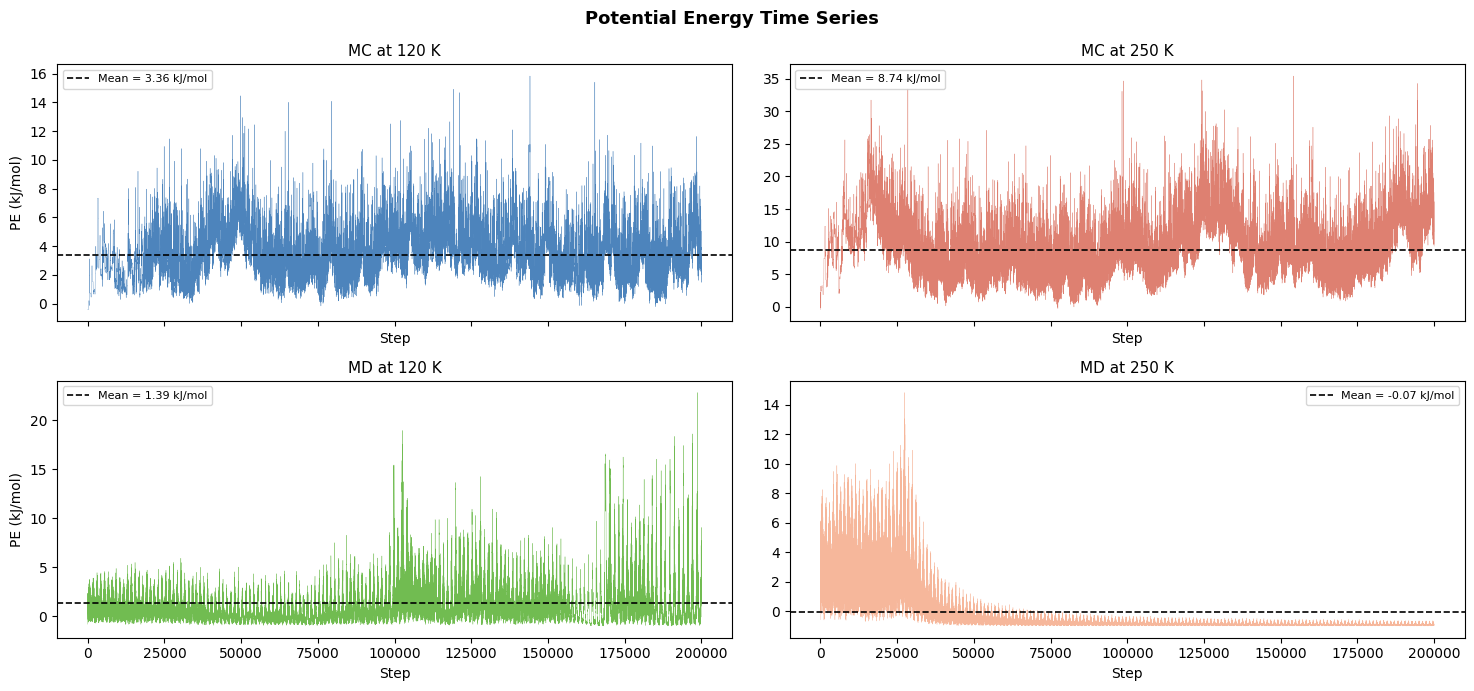

Saved: plots/energy_timeseries.png


In [118]:
# ─────────────────────────────────────────────────────────────────────────────
# Cell 8 — Task 2 Analysis: MC vs MD Comparison at 120 K and 250 K
# ─────────────────────────────────────────────────────────────────────────────

# ── Use precomputed MC/MD results (no re-run) ───────────────────────────────
required_temps = [120, 250]

if 'mc_results' not in globals() or 'md_results' not in globals():
    raise RuntimeError(
        "MC/MD results not found. Run the MC and MD baseline cells first, "
        "then re-run this cell to plot the comparison."
    )

results = {}
for T in required_temps:
    if T not in mc_results or T not in md_results:
        raise RuntimeError(
            f"Missing results for {T} K. Ensure both MC and MD have been run at {T} K."
        )
    results[f'MC_{T}'] = {
        'dihedrals': mc_results[T]['dihedrals'],
        'energies': mc_results[T]['energies'],
        'acceptance': mc_results[T].get('acceptance', float('nan')),
        'label': f'MC  {T} K',
    }
    results[f'MD_{T}'] = {
        'dihedrals': md_results[T]['dihedrals'],
        'energies': md_results[T]['energies'],
        'temps': md_results[T].get('temps', None),
        'label': f'MD  {T} K',
    }

print("Using precomputed MC/MD results for comparison plots.")

# ── Helper: count barrier crossings ──────────────────────────────────────────

def count_crossings(dihedrals, threshold=90.0):
    """Count steps where |Δφ| > threshold — proxy for trans↔gauche transitions."""
    return int(np.sum(np.abs(np.diff(dihedrals)) > threshold))

def conformation_fractions(dihedrals):
    """Return fraction of time in trans, gauche+, gauche−, other."""
    d = np.array(dihedrals)
    trans   = np.mean((np.abs(d) > 120))
    gauchep = np.mean((d >  30) & (d <  120))
    gauchem = np.mean((d < -30) & (d > -120))
    other   = 1.0 - trans - gauchep - gauchem
    return {'trans': trans, 'gauche+': gauchep, 'gauche-': gauchem, 'other': other}

# ── Print summary statistics ──────────────────────────────────────────────────
print(f"\n{'─'*72}")
print(f"{'Method':<10} {'T(K)':<6} {'Acc%':>6} {'Crossings':>10} "
      f"{'Trans%':>8} {'G+%':>7} {'G-%':>7}")
print(f"{'─'*72}")

for key, res in results.items():
    d   = res['dihedrals']
    acc = res.get('acceptance', float('nan'))
    cr  = count_crossings(d)
    cf  = conformation_fractions(d)
    method, T_str = key.split('_')

# ── Figure 1: Dihedral time series (2 × 2) ───────────────────────────────────

COLORS = {'MC_120': '#2166ac', 'MD_120': '#4dac26',
          'MC_250': '#d6604d', 'MD_250': '#f4a582'}

fig1, axes = plt.subplots(2, 2, figsize=(15, 8), sharey=True)
fig1.suptitle("Dihedral Angle Time Series — MC vs MD at 120 K and 250 K",
              fontsize=14, fontweight='bold', y=1.01)

REFERENCE_LINES = [
    ( 180, 'gray',   '--', 'trans (±180°)'),
    (-180, 'gray',   '--', None),
    (  60, '#1b7837','-.', 'gauche+ (60°)'),
    ( -60, '#762a83','-.', 'gauche− (−60°)'),
]

panel_keys = [('MC_120', 0, 0), ('MC_250', 0, 1),
              ('MD_120', 1, 0), ('MD_250', 1, 1)]

for key, row, col in panel_keys:
    ax  = axes[row, col]
    d   = results[key]['dihedrals']
    acc = results[key].get('acceptance', float('nan'))
    cr  = count_crossings(d)
    steps = np.arange(len(d))

    ax.plot(steps, d, lw=0.25, alpha=0.75, color=COLORS[key], rasterized=True)

    for yval, c, ls, lbl in REFERENCE_LINES:
        ax.axhline(yval, color=c, ls=ls, lw=1.0,
                   label=lbl if lbl else '_nolegend_')

    method, T_str = key.split('_')
    title = f"{method} at {T_str} K  |  crossings={cr}"
    if not np.isnan(acc):
        title += f"  |  acc={acc*100:.1f}%"
    ax.set_title(title, fontsize=11)
    ax.set_ylim(-185, 185)
    ax.set_yticks([-180, -120, -60, 0, 60, 120, 180])
    ax.set_xlim(0, len(d))
    ax.set_xlabel("Step", fontsize=10)
    if col == 0:
        ax.set_ylabel("Dihedral φ C1-C2-C3-C4 (°)", fontsize=10)

# Shared legend on row 0 col 0
axes[0, 0].legend(fontsize=8, loc='lower right', framealpha=0.7)

plt.tight_layout()
plt.savefig("plots/comparison_timeseries.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved: comparison_timeseries.png")

# ── Figure 2: Dihedral histograms (2 × 2, 36 bins) ───────────────────────────

BINS       = 36
BIN_EDGES  = np.linspace(-180, 180, BINS + 1)
BIN_CENTERS = 0.5 * (BIN_EDGES[:-1] + BIN_EDGES[1:])

fig2, axes2 = plt.subplots(2, 2, figsize=(15, 8))
fig2.suptitle("Dihedral Distributions (36 bins) — MC vs MD at 120 K and 250 K",
              fontsize=14, fontweight='bold', y=1.01)

for key, row, col in panel_keys:
    ax  = axes2[row, col]
    d   = results[key]['dihedrals']
    method, T_str = key.split('_')

    counts, _ = np.histogram(d, bins=BIN_EDGES)
    probs      = counts / counts.sum()

    ax.bar(BIN_CENTERS, probs, width=360/BINS - 0.5,
           color=COLORS[key], alpha=0.8, edgecolor='white', lw=0.4)

    # Annotate conformation wells
    cf = conformation_fractions(d)
    for xv, label, c in [(180, f"trans\n{cf['trans']*100:.0f}%",   'gray'),
                          ( 60, f"g+\n{cf['gauche+']*100:.0f}%",   '#1b7837'),
                          (-60, f"g−\n{cf['gauche-']*100:.0f}%",   '#762a83')]:
        ax.axvline(xv, color=c, ls='--', lw=1.5)
        ax.axvline(-xv if xv == 180 else xv, color=c, ls='--', lw=1.0,
                   alpha=0.4)

    ax.set_title(f"{method} at {T_str} K", fontsize=11)
    ax.set_xlabel("Dihedral φ (degrees)", fontsize=10)
    ax.set_ylabel("Probability", fontsize=10)
    ax.set_xlim(-180, 180)
    ax.set_xticks(np.arange(-180, 181, 60))

plt.tight_layout()
plt.savefig("plots/comparison_histograms.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved: plots/comparison_histograms.png")

# ── Figure 3: MC vs MD overlay at same temperature ───────────────────────────

fig3, axes3 = plt.subplots(1, 2, figsize=(13, 5))
fig3.suptitle("MC vs MD Dihedral Distribution Overlay",
              fontsize=13, fontweight='bold')

for col, T in enumerate([120, 250]):
    ax = axes3[col]

    for method, color, ls in [('MC', COLORS[f'MC_{T}'], '-'),
                               ('MD', COLORS[f'MD_{T}'], '--')]:
        d      = results[f'{method}_{T}']['dihedrals']
        counts, _ = np.histogram(d, bins=BIN_EDGES)
        probs     = counts / counts.sum()
        ax.step(BIN_CENTERS, probs, where='mid',
                color=color, lw=2, ls=ls, label=method, alpha=0.9)

    ax.axvline( 180, color='gray',   ls=':', lw=1)
    ax.axvline(-180, color='gray',   ls=':', lw=1)
    ax.axvline(  60, color='#1b7837', ls=':', lw=1, label='gauche+')
    ax.axvline( -60, color='#762a83', ls=':', lw=1, label='gauche−')
    ax.set_title(f"MC vs MD at {T} K", fontsize=12)
    ax.set_xlabel("Dihedral φ (degrees)", fontsize=10)
    ax.set_ylabel("Probability", fontsize=10)
    ax.set_xlim(-180, 180)
    ax.set_xticks(np.arange(-180, 181, 60))
    ax.legend(fontsize=10)

plt.tight_layout()
plt.savefig("plots/mc_vs_md_overlay.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved: plots/mc_vs_md_overlay.png")

# ── Figure 4: Energy time series ─────────────────────────────────────────────

fig4, axes4 = plt.subplots(2, 2, figsize=(15, 7), sharex=True)
fig4.suptitle("Potential Energy Time Series", fontsize=13, fontweight='bold')

for key, row, col in panel_keys:
    ax = axes4[row, col]
    e  = results[key]['energies']
    method, T_str = key.split('_')
    steps = np.arange(len(e))
    ax.plot(steps, e, lw=0.25, alpha=0.8, color=COLORS[key], rasterized=True)
    ax.axhline(np.mean(e), color='black', ls='--', lw=1.2,
               label=f'Mean = {np.mean(e):.2f} kJ/mol')
    ax.set_title(f"{method} at {T_str} K", fontsize=11)
    ax.set_xlabel("Step", fontsize=10)
    if col == 0:
        ax.set_ylabel("PE (kJ/mol)", fontsize=10)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig("plots/energy_timeseries.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved: plots/energy_timeseries.png")

### Umbrella sampling with WHAM
Runs umbrella-biased MC windows, combines them with WHAM to get the unbiased PMF, and plots window diagnostics and results.


  Umbrella Sampling at 120 K
  36 windows × 5555 steps  |  K_US = 16.6289 kJ/mol/rad²  |  move_size = 0.05 Å
    Window  1/36  φ₀= -175.0°  mean_φ=  -26.0°  acc=34.5%
    Window  9/36  φ₀=  -95.0°  mean_φ=  -92.8°  acc=35.4%
    Window 18/36  φ₀=   -5.0°  mean_φ=  -61.6°  acc=35.5%
    Window 27/36  φ₀=   85.0°  mean_φ=   78.3°  acc=34.5%
    Window 36/36  φ₀=  175.0°  mean_φ=  102.2°  acc=34.1%
  Mean acceptance: 34.8%
  Running WHAM ...
  WHAM bins populated: 35/36
  Total samples: 199980  |  naive bins populated: 36/36

  Umbrella Sampling at 250 K
  36 windows × 5555 steps  |  K_US = 16.6289 kJ/mol/rad²  |  move_size = 0.1 Å
    Window  1/36  φ₀= -175.0°  mean_φ=    0.3°  acc=24.1%
    Window  9/36  φ₀=  -95.0°  mean_φ= -137.9°  acc=24.2%
    Window 18/36  φ₀=   -5.0°  mean_φ=  -62.3°  acc=23.1%
    Window 27/36  φ₀=   85.0°  mean_φ=   79.2°  acc=22.7%
    Window 36/36  φ₀=  175.0°  mean_φ=   35.5°  acc=23.4%
  Mean acceptance: 23.5%
  Running WHAM ...
  WHAM bins populated: 36/36

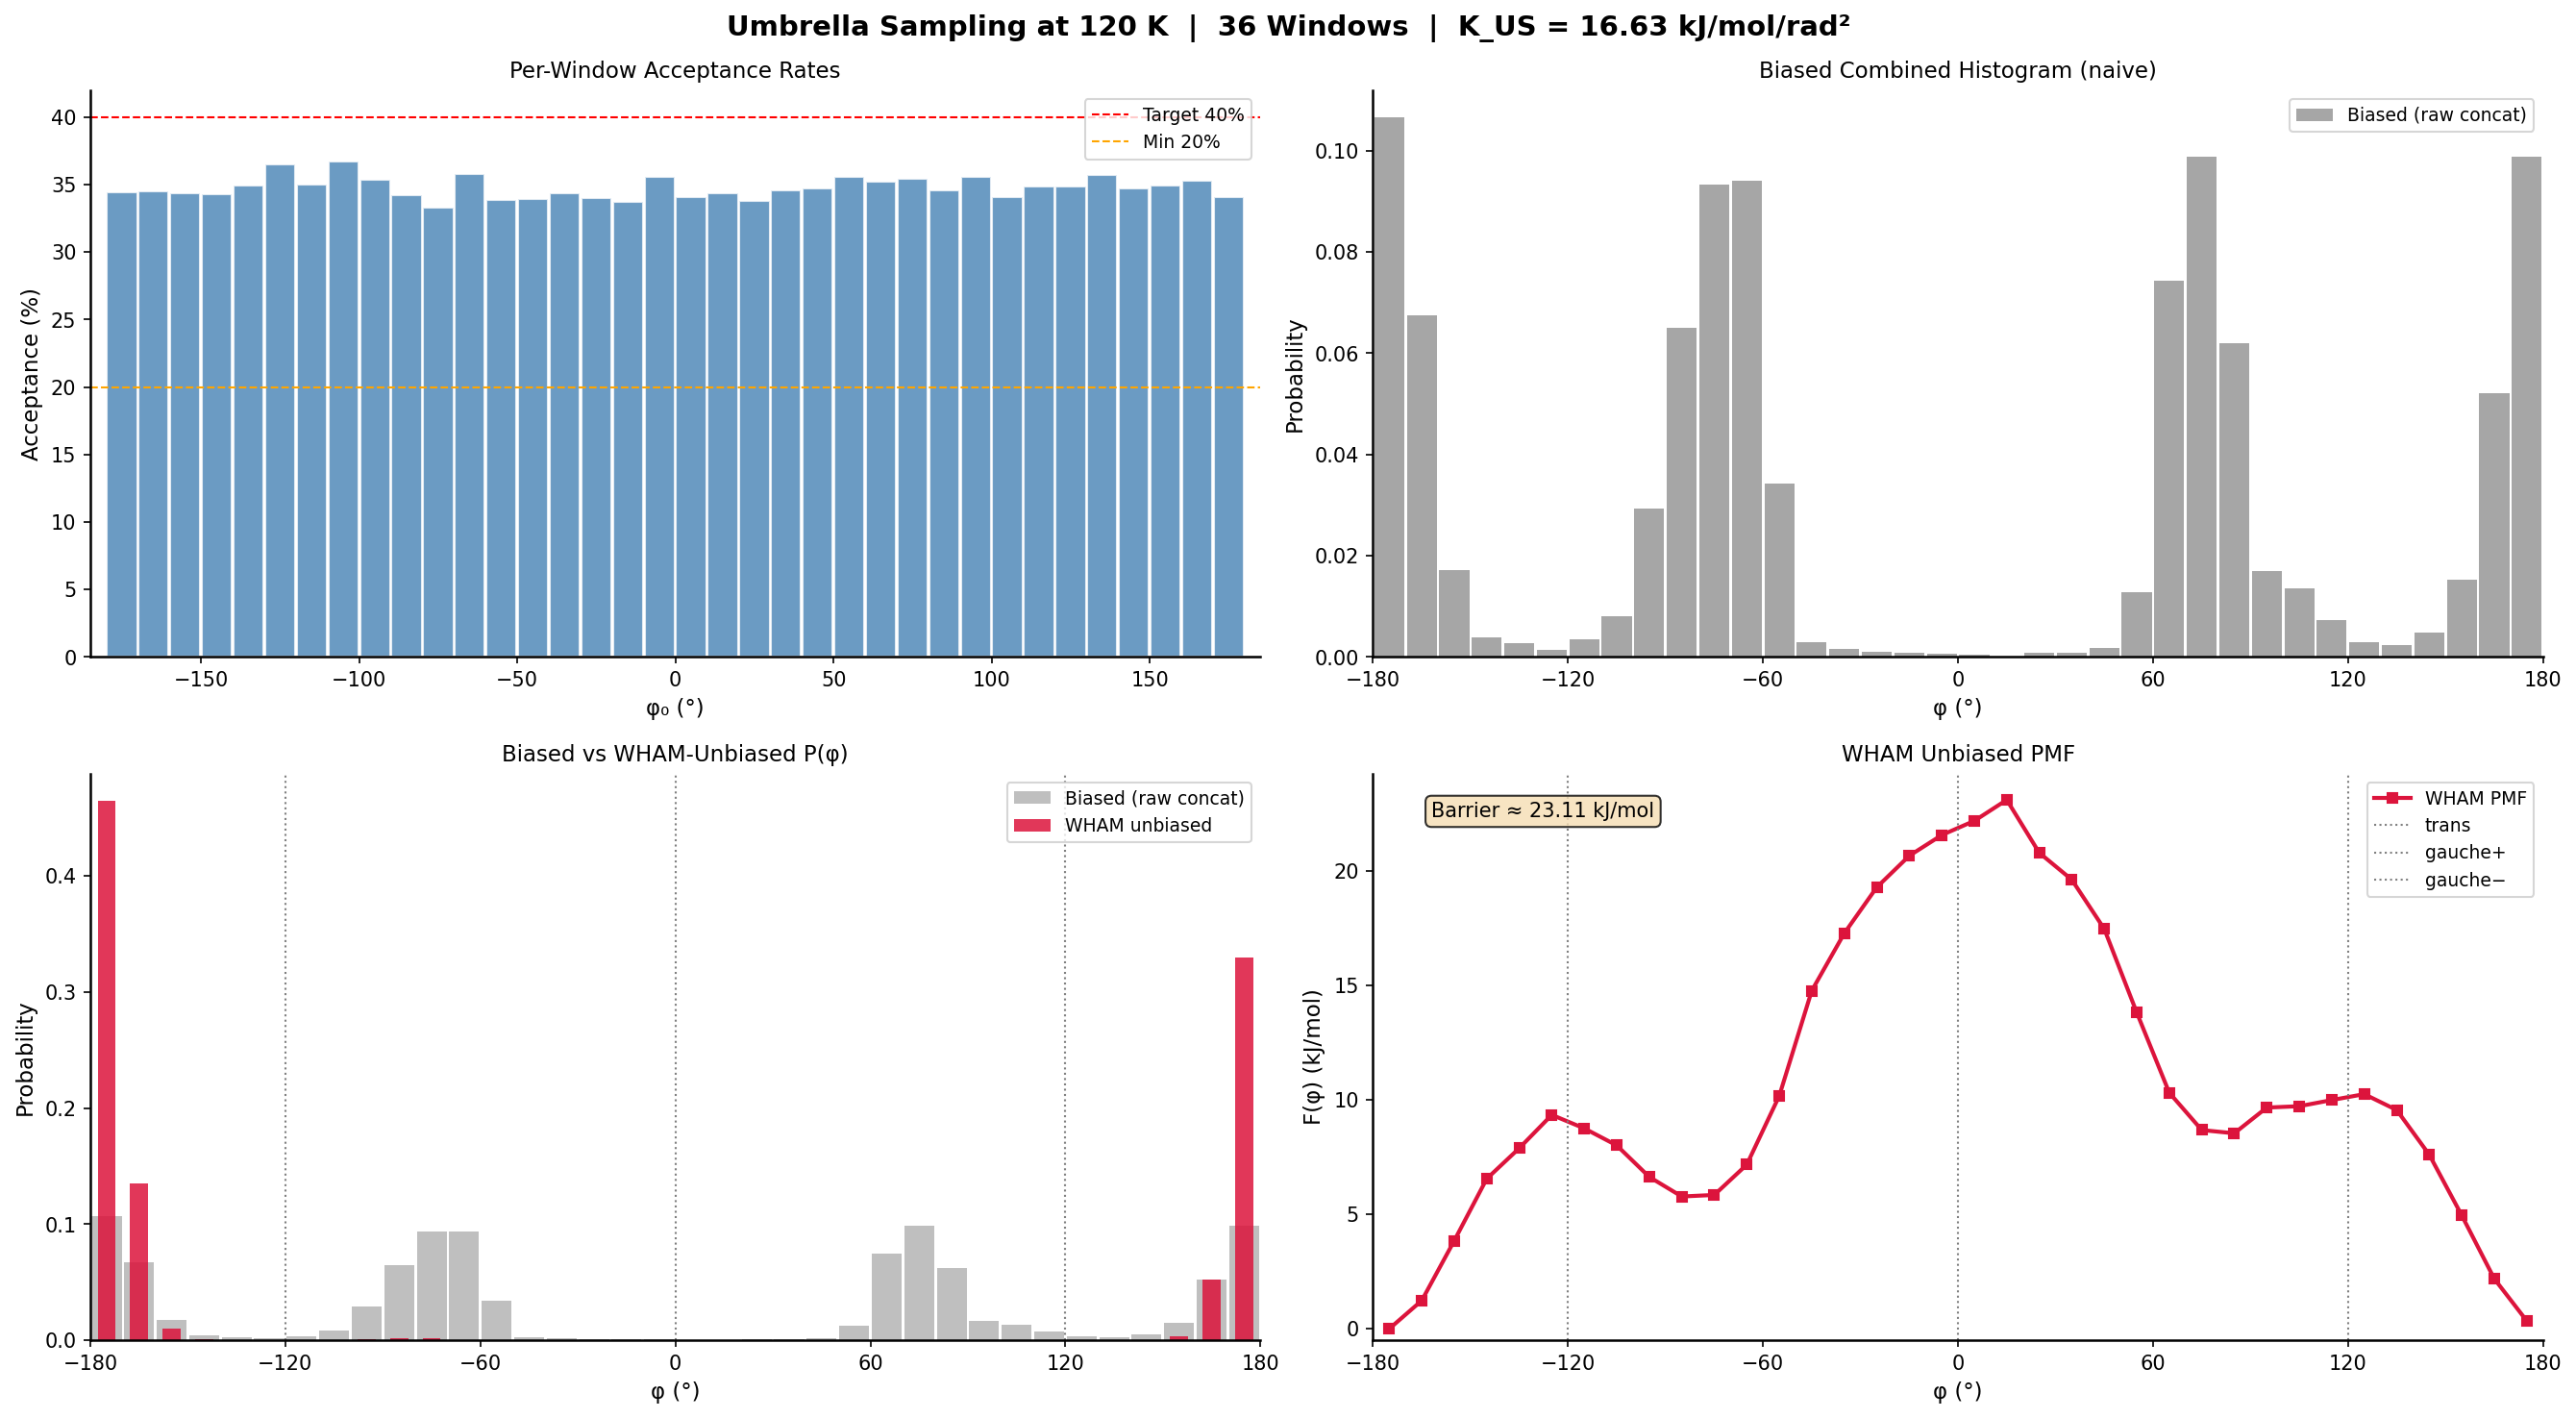

Saved: plots/enhanced_umbrella_120K.png


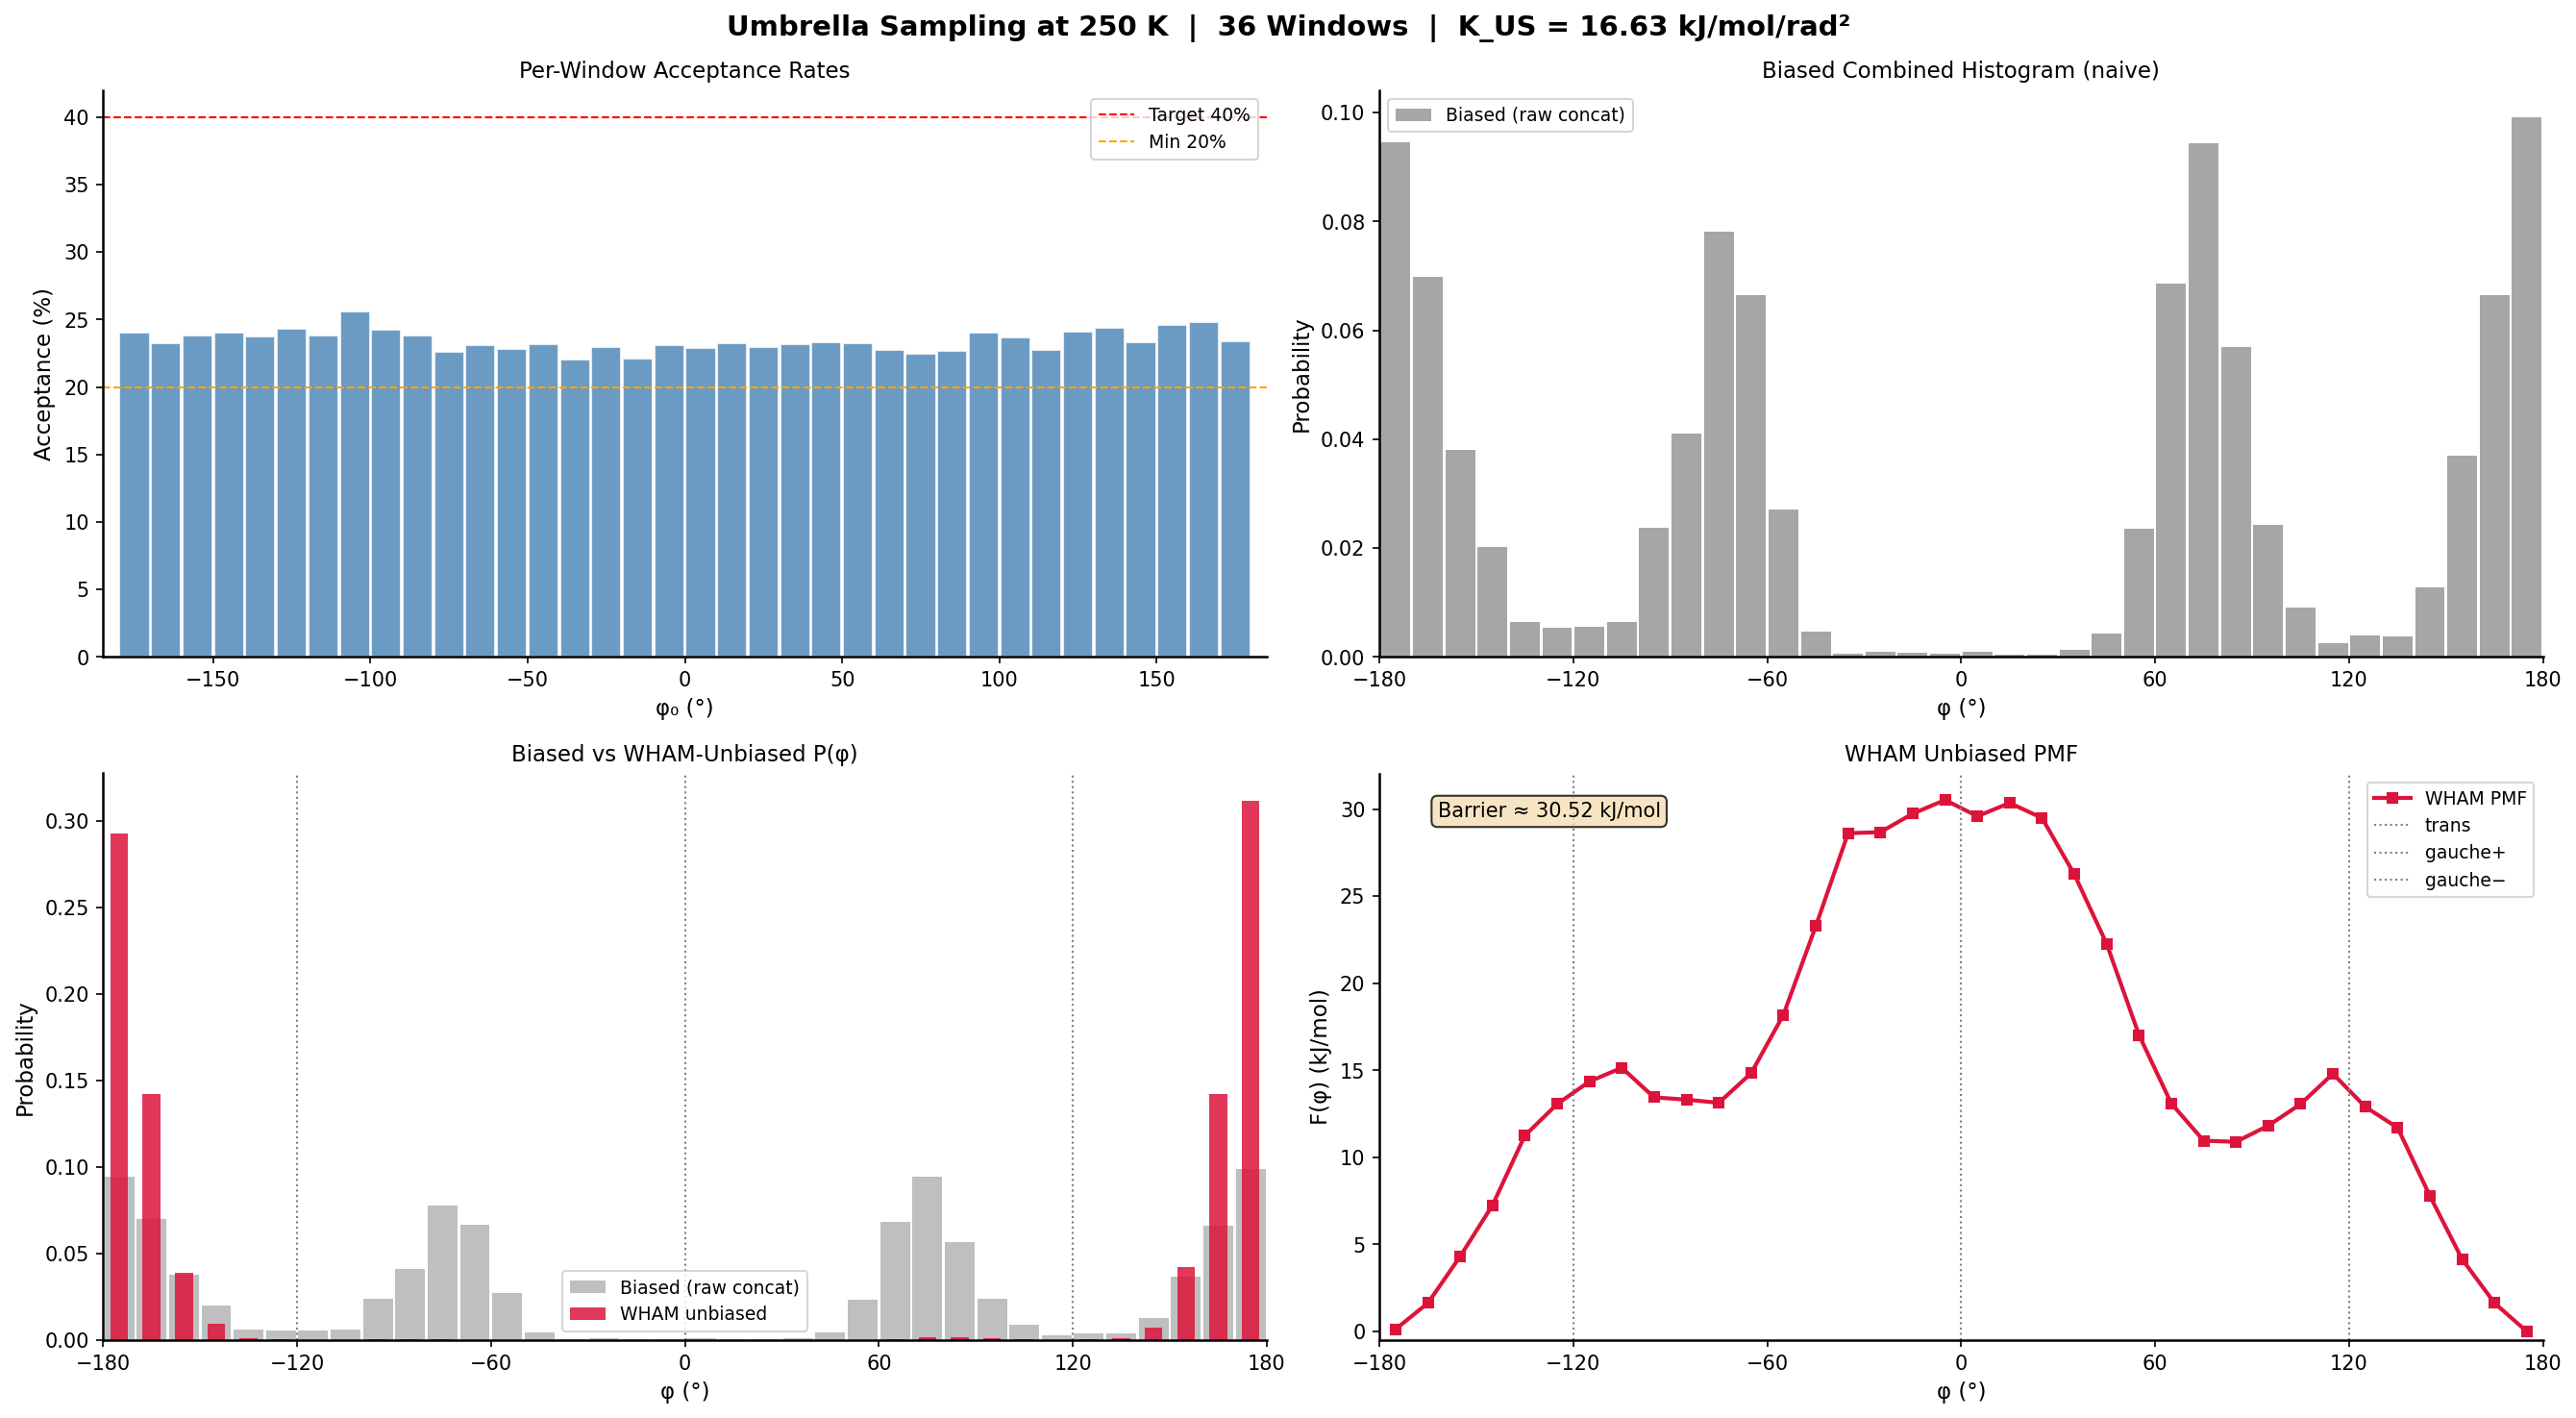

Saved: plots/enhanced_umbrella_250K.png


In [125]:
# ─────────────────────────────────────────────────────────────────────────────
# Cell 9 — Task 3: Enhanced Sampling via Umbrella Sampling + WHAM
#
# Rewritten to exactly match pentane_core.py conventions:
#   - All angles in RADIANS (PHI_CENTERS from core are in radians)
#   - K_US = 2000*kB [J/rad²] — the core's spring constant
#   - run_US_window from core used directly (no custom MC)
#   - wham() from core used directly (angles in radians, energy in J)
#   - build_coords_at_phi(phi_0) for per-window starting configs
#   - np.random.seed for reproducibility (core uses np.random, not rng)
# ─────────────────────────────────────────────────────────────────────────────

import numpy as np
import matplotlib.pyplot as plt
import sys, importlib

# ── Import from pentane_core ──────────────────────────────────────────────────
import pentane_core as pc
importlib.reload(pc)
from pentane_core import (
    kB, J_TO_KJMOL,
    N_WINDOWS, PHI_CENTERS, K_US, STEPS_PER_WINDOW,
    BIN_EDGES, BIN_CENTERS, BIN_WIDTH, N_BINS,
    build_pentane_trans, build_coords_at_phi,
    run_US_window,
    make_histogram, combine_US_histograms,
    wham,
    compute_PMF, exploration_entropy, running_entropy, count_barrier_crossings,
)

# ── Run full umbrella sampling pipeline ──────────────────────────────────────

def run_umbrella_sampling(T, seed_base=42):
    """
    Full umbrella sampling at temperature T, matching pentane_core exactly.

    - PHI_CENTERS: 36 bin centres in radians [-π, π]
    - K_US = 2000*kB J/rad² (~16.63 kJ/mol/rad²)
    - STEPS_PER_WINDOW = N_STEPS // N_WINDOWS = 200000 // 36 = 5555 steps
    - Starting config: build_coords_at_phi(phi_0) — each window starts AT phi_0
    - move_size: 0.10 Å at 250 K, 0.05 Å at 120 K (matches friend's notebook)
    - Seeds: seed_base + window_index, set via np.random.seed (core uses np.random)
    """
    move_size = 0.05 if T == 120 else 0.10

    print(f"\n  Umbrella Sampling at {T} K")
    print(f"  {N_WINDOWS} windows × {STEPS_PER_WINDOW} steps  "
          f"|  K_US = {K_US * J_TO_KJMOL:.4f} kJ/mol/rad²  "
          f"|  move_size = {move_size} Å")

    window_dihedrals = []
    window_acc       = []

    for w_idx, phi0 in enumerate(PHI_CENTERS):
        # Seed reproducibly per window — core uses np.random.seed
        np.random.seed(seed_base + w_idx)

        # Start each window AT the window centre (not all-trans)
        pos_start = build_coords_at_phi(phi0)

        dihs, acc = run_US_window(
            coords_init  = pos_start,
            T            = T,
            phi_0        = phi0,          # radians
            k_us         = K_US,          # J/rad²
            n_steps      = STEPS_PER_WINDOW,
            move_size_ang= move_size,
        )
        window_dihedrals.append(dihs)
        window_acc.append(acc)

        if (w_idx + 1) % 9 == 0 or w_idx == 0:
            print(f"    Window {w_idx+1:>2}/{N_WINDOWS}  "
                  f"φ₀={np.degrees(phi0):>7.1f}°  "
                  f"mean_φ={np.degrees(dihs.mean()):>7.1f}°  "
                  f"acc={acc*100:.1f}%")

    print(f"  Mean acceptance: {np.mean(window_acc)*100:.1f}%")

    # ── Build per-window histograms for WHAM ─────────────────────────────
    window_hists = []
    for dihs in window_dihedrals:
        counts, _ = make_histogram(dihs)       # uses BIN_EDGES in radians
        window_hists.append(counts)

    # ── WHAM ─────────────────────────────────────────────────────────────
    print(f"  Running WHAM ...")
    P_wham, F_wham = wham(
        window_hists   = window_hists,
        window_centers = PHI_CENTERS,   # radians
        K_US_val       = K_US,          # J/rad²
        T              = T,
        bin_centers    = BIN_CENTERS,   # radians
    )
    assert np.all(np.isfinite(P_wham)), f"WHAM did not converge at {T} K"
    print(f"  WHAM bins populated: {np.sum(P_wham > 1e-10)}/36")

    # ── Naive combined histogram (biased, no WHAM) ────────────────────────
    counts_combined, P_naive, combined_dihs = combine_US_histograms(window_dihedrals)
    print(f"  Total samples: {len(combined_dihs)}  |  "
          f"naive bins populated: {np.sum(counts_combined > 0)}/36")

    # ── Barrier crossings in concatenated trajectory ──────────────────────
    crossings = count_barrier_crossings(combined_dihs, threshold_deg=60.0)

    # ── Entropy from WHAM-unbiased P ─────────────────────────────────────
    S_final = exploration_entropy(P_wham)

    return {
        # Keys used by cells 10–13
        'cold_dihedrals'  : combined_dihs,
        'cold_energies'   : np.zeros(len(combined_dihs)),  # not tracked by run_US_window
        'centers'         : [],
        'heights'         : [],
        'acceptance'      : float(np.mean(window_acc)),
        'crossings'       : crossings,
        'bin_centers'     : BIN_CENTERS,          # radians
        'p_biased'        : P_naive,
        'p_unbias'        : P_wham,
        # WHAM / per-window extras
        'wham_pmf'        : F_wham,               # kJ/mol, min=0
        'wham_P'          : P_wham,
        'window_dihedrals': window_dihedrals,
        'window_hists'    : window_hists,
        'window_phi0s'    : PHI_CENTERS,          # radians
        'window_acc'      : window_acc,
        'K_US'            : K_US,
        'T_list'          : [T],
        'swap_stats'      : {},
        'S_final'         : S_final,
    }


# ─────────────────────────────────────────────────────────────────────────────
# Run at both temperatures
# ─────────────────────────────────────────────────────────────────────────────

enhanced_results = {}
for T in [120, 250]:
    enhanced_results[T] = run_umbrella_sampling(T, seed_base=42)


# ─────────────────────────────────────────────────────────────────────────────
# Plotting — matches friend's plot19, plot14, plot17 style
# ─────────────────────────────────────────────────────────────────────────────

deg_centers = np.degrees(BIN_CENTERS)   # for all plots

for T in [120, 250]:
    er  = enhanced_results[T]
    n_w = len(er['window_phi0s'])
    BAR_W = np.degrees(BIN_WIDTH) - 0.8

    fig, axes = plt.subplots(2, 2, figsize=(18, 10))
    fig.suptitle(
        f"Umbrella Sampling at {T} K  |  36 Windows  |  "
        f"K_US = {K_US * J_TO_KJMOL:.2f} kJ/mol/rad²",
        fontsize=14, fontweight='bold'
    )


    # ── (0,1) Per-window acceptance rates ────────────────────────────────
    ax = axes[0, 0]
    ax.bar(np.degrees(er['window_phi0s']), np.array(er['window_acc']) * 100,
           width=360 / n_w - 0.5, color='steelblue', alpha=0.8, edgecolor='white')
    ax.axhline(40, color='red',    ls='--', lw=1, label='Target 40%')
    ax.axhline(20, color='orange', ls='--', lw=1, label='Min 20%')
    ax.set_title("Per-Window Acceptance Rates", fontsize=11)
    ax.set_xlabel("φ₀ (°)"); ax.set_ylabel("Acceptance (%)")
    ax.set_xlim(-185, 185); ax.legend(fontsize=9)

    # ── (0,2) Naive biased histogram ─────────────────────────────────────
    ax = axes[0, 1]
    ax.bar(deg_centers, er['p_biased'], width=BAR_W,
           color='gray', alpha=0.7, label='Biased (raw concat)')
    ax.set_title("Biased Combined Histogram (naive)", fontsize=11)
    ax.set_xlabel("φ (°)"); ax.set_ylabel("Probability")
    ax.set_xlim(-180, 180); ax.set_xticks(np.arange(-180, 181, 60))
    ax.legend(fontsize=9)

    # ── (1,0) Biased vs WHAM unbiased P(φ) ───────────────────────────────
    ax = axes[1, 0]
    ax.bar(deg_centers, er['p_biased'], width=BAR_W,
           color='gray', alpha=0.5, label='Biased (raw concat)')
    ax.bar(deg_centers, er['wham_P'], width=BAR_W * 0.6,
           color='crimson', alpha=0.85, label='WHAM unbiased')
    for xv in [0, 120, -120]:
        ax.axvline(xv, color='gray', ls=':', lw=1)
    ax.set_title("Biased vs WHAM-Unbiased P(φ)", fontsize=11)
    ax.set_xlabel("φ (°)"); ax.set_ylabel("Probability")
    ax.set_xlim(-180, 180); ax.set_xticks(np.arange(-180, 181, 60))
    ax.legend(fontsize=9)

    # ── (1,1) WHAM PMF ────────────────────────────────────────────────────
    ax = axes[1, 1]
    ax.plot(deg_centers, er['wham_pmf'], 's-', lw=2, ms=5,
            color='crimson', label='WHAM PMF')
    for xv, lbl in [(0, 'trans'), (120, 'gauche+'), (-120, 'gauche−')]:
        ax.axvline(xv, color='gray', ls=':', lw=1, label=lbl)
    barrier = np.nanmax(er['wham_pmf']) - np.nanmin(er['wham_pmf'])
    ax.annotate(f"Barrier ≈ {barrier:.2f} kJ/mol",
                xy=(0.05, 0.95), xycoords='axes fraction',
                fontsize=10, va='top',
                bbox=dict(boxstyle='round', fc='wheat', alpha=0.8))
    ax.set_title("WHAM Unbiased PMF", fontsize=11)
    ax.set_xlabel("φ (°)"); ax.set_ylabel("F(φ) (kJ/mol)")
    ax.set_xlim(-180, 180); ax.set_xticks(np.arange(-180, 181, 60))
    ax.set_ylim(bottom=-0.5); ax.legend(fontsize=9)

    plt.tight_layout()
    plt.savefig(f"plots/enhanced_umbrella_{T}K.png", dpi=150)
    plt.show()
    print(f"Saved: plots/enhanced_umbrella_{T}K.png")

### Exploration entropy metrics
Computes entropy-based exploration scores, prints metrics, and plots entropy and bin coverage over time.

Unique bins in first 36 US samples: 36  (want ~36)
US combined 120K length: 199980
First 5 values (degrees): [-175. -165. -155. -145. -135.]
Computing running entropy (takes ~30s)...

Method             T(K)     Final S   Early E
------------------------------------------------------------
  MC               120       0.9259    0.8174
  MC               250       1.4536    1.3967
  MD               120       2.7730    2.5797
  MD               250       1.3093    1.7867
  Enhanced         120       2.8253    2.9961
  Enhanced         250       2.9589    3.1015
S_max = ln(36) = 3.5835


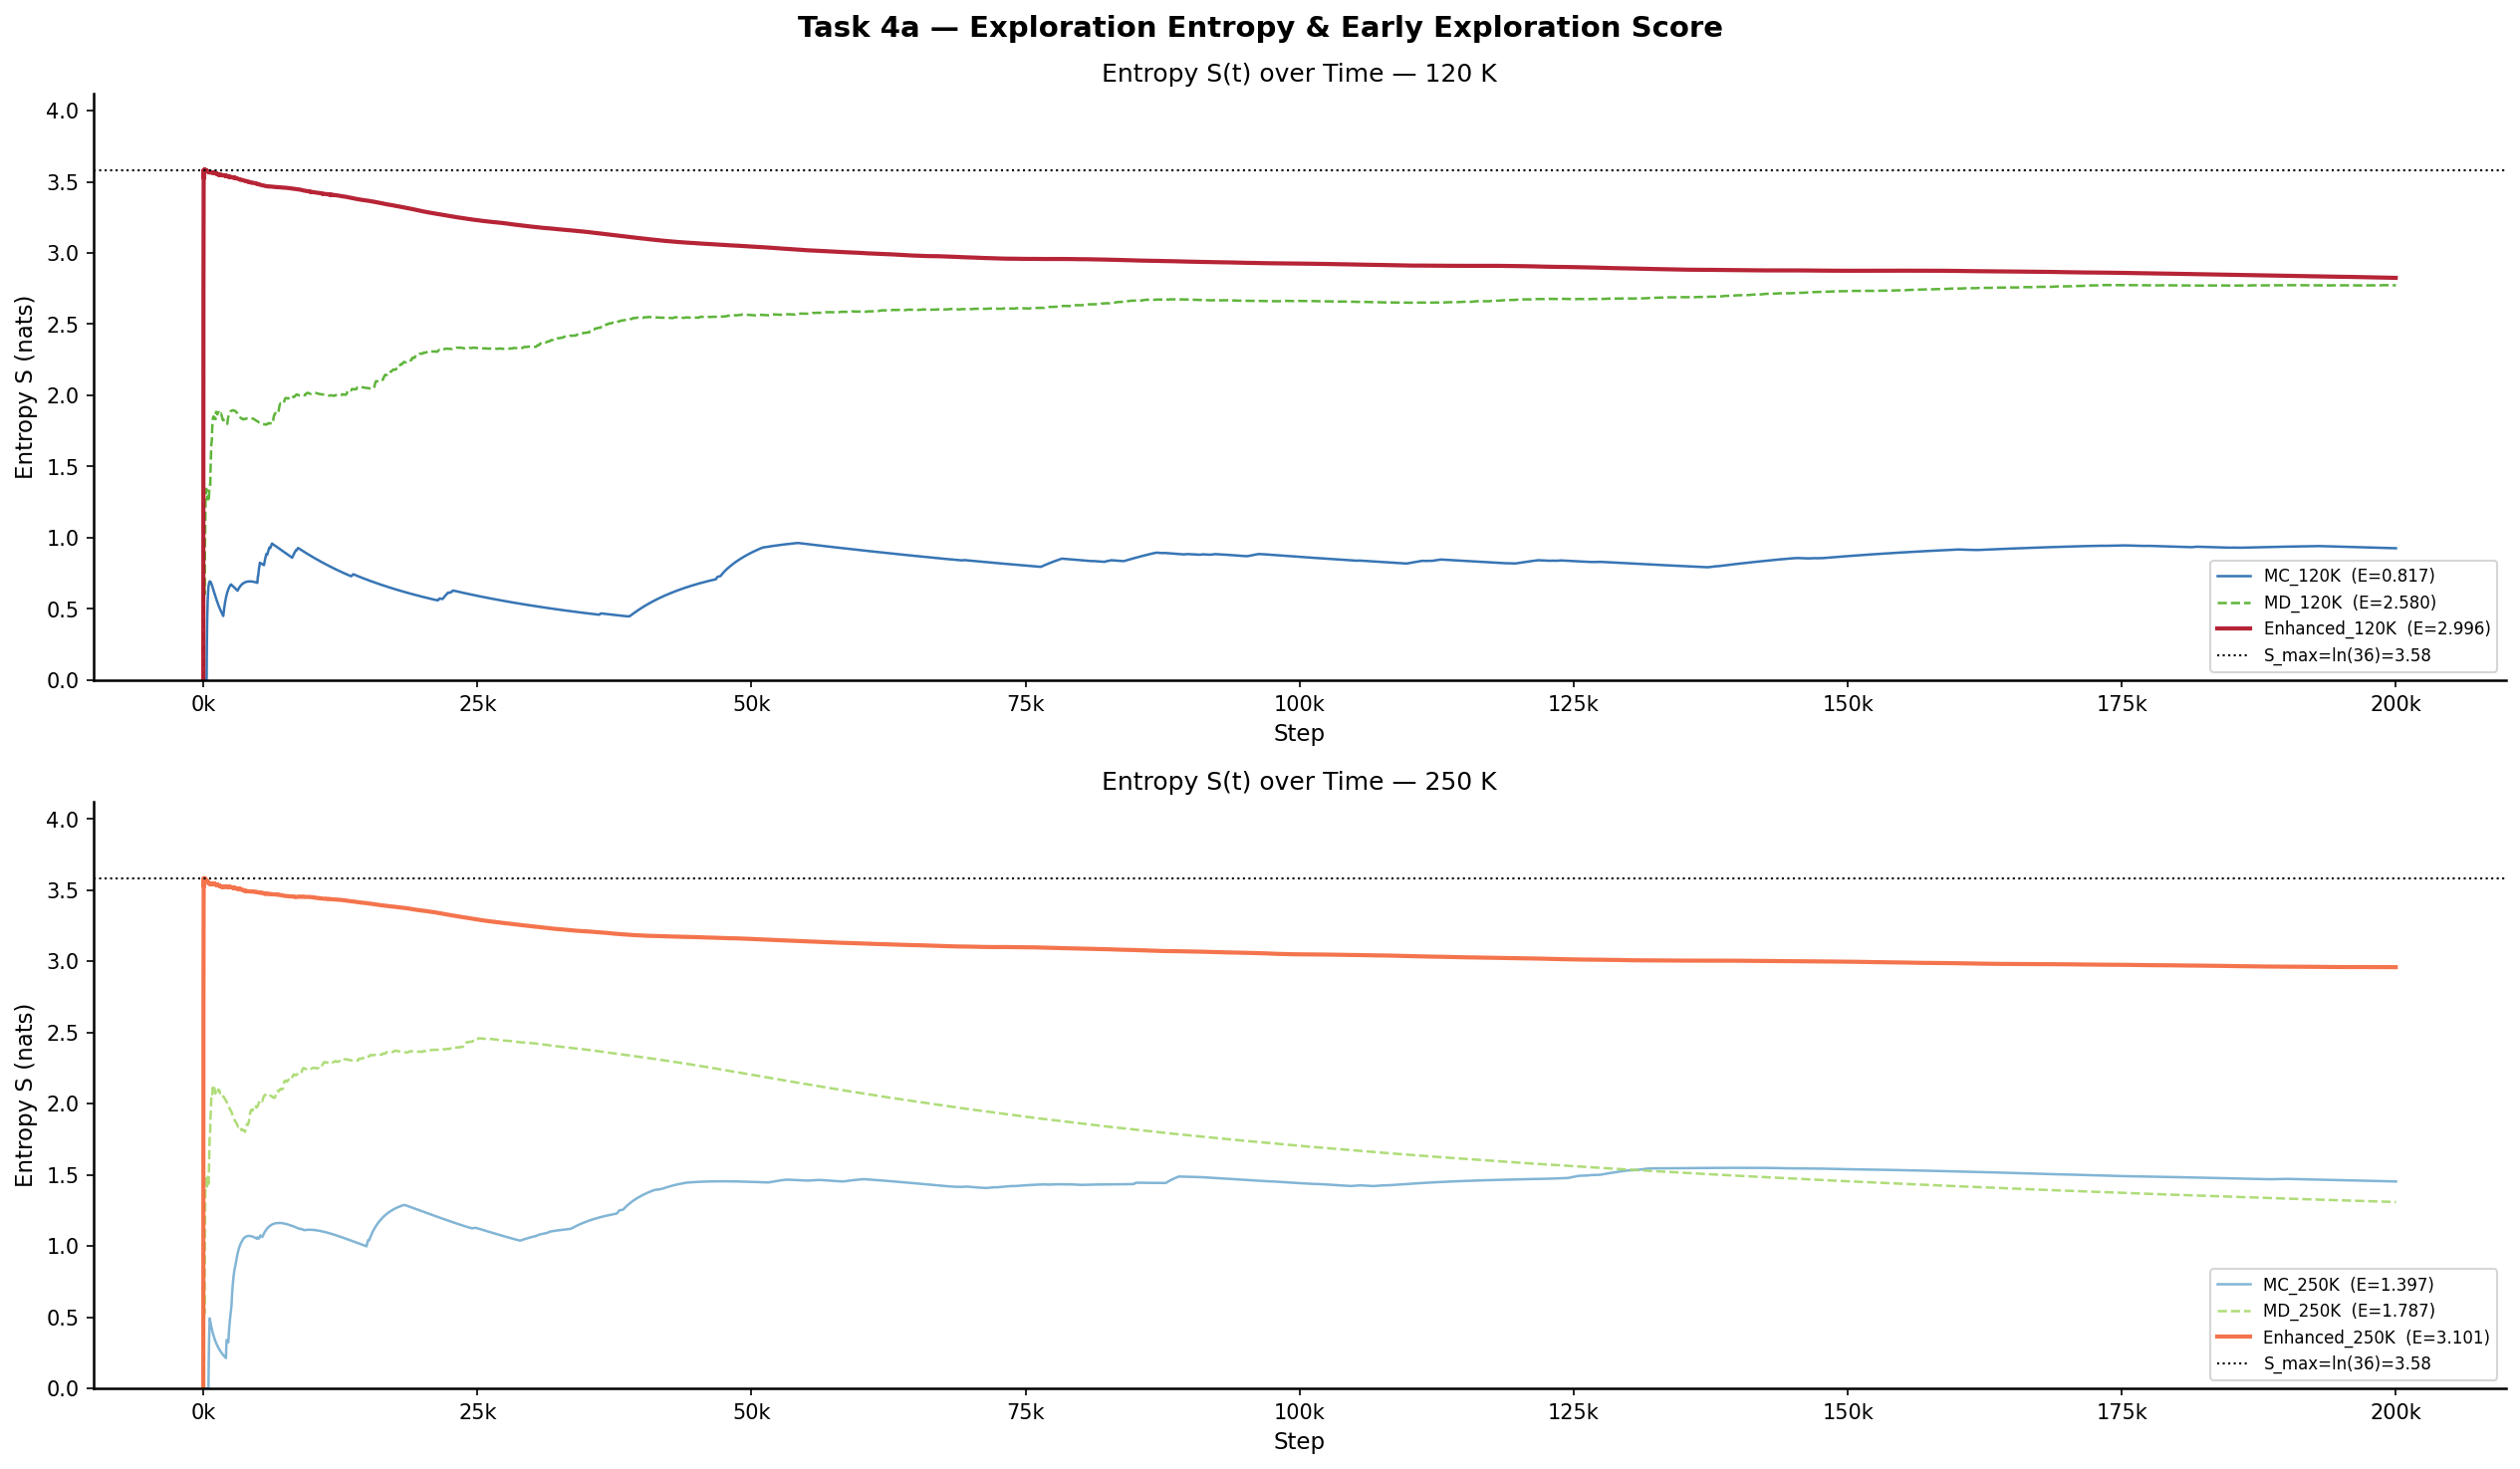

Saved: plots/entropy_analysis.png


In [134]:
# ─────────────────────────────────────────────────────────────────────────────
# Cell 10 — Task 4a: Exploration Entropy & Early Exploration Score  [FIXED]
# ─────────────────────────────────────────────────────────────────────────────

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

N_BINS    = 36
BIN_EDGES = np.linspace(-180, 180, N_BINS + 1)
S_MAX     = np.log(N_BINS)


def running_entropy(dihedrals_deg):
    """S(t) computed step by step on a degrees array."""
    d = np.asarray(dihedrals_deg, dtype=float)
    n = len(d)
    counts = np.zeros(N_BINS, dtype=float)
    S_traj = np.zeros(n)
    for t in range(n):
        b = np.searchsorted(BIN_EDGES, d[t], side='right') - 1
        b = int(np.clip(b, 0, N_BINS - 1))
        counts[b] += 1.0
        P = counts / counts.sum()
        P_nz = P[P > 0]
        S_traj[t] = -np.sum(P_nz * np.log(P_nz))
    return S_traj, float(np.mean(S_traj))


def make_us_combined(enhanced_T):
    """
    Interleave all window dihedrals so the combined array hits every
    bin immediately. window_dihedrals is a list of 36 arrays in radians
    — convert to degrees here.
    """
    arrays = enhanced_T['window_dihedrals']   # list of 36 arrays, radians
    arrays_deg = [np.degrees(np.asarray(a)) for a in arrays]
    min_len = min(len(a) for a in arrays_deg)
    arrays_deg = [a[:min_len] for a in arrays_deg]
    # shape (min_len, 36) → flatten row-major = interleaved
    stacked  = np.stack(arrays_deg, axis=1)   # (min_len, 36)
    combined = stacked.flatten()              # (min_len*36,)  interleaved
    return combined


# ── Build interleaved US arrays ───────────────────────────────────────────────

us_combined_120 = make_us_combined(enhanced_results[120])
us_combined_250 = make_us_combined(enhanced_results[250])

# Verify it worked
bins_first36 = np.searchsorted(BIN_EDGES, us_combined_120[:36], side='right') - 1
print(f"Unique bins in first 36 US samples: {len(np.unique(bins_first36))}  (want ~36)")
print(f"US combined 120K length: {len(us_combined_120)}")
print(f"First 5 values (degrees): {us_combined_120[:5].round(1)}")


# ── MC/MD dihedrals — convert to degrees if in radians ───────────────────────

def to_degrees(arr):
    arr = np.asarray(arr, dtype=float)
    # if values are in [-pi, pi] range → radians, convert
    if np.abs(arr).max() <= 4.0:
        return np.degrees(arr)
    return arr   # already degrees

mc_120 = to_degrees(results['MC_120']['dihedrals'])
mc_250 = to_degrees(results['MC_250']['dihedrals'])
md_120 = to_degrees(results['MD_120']['dihedrals'])
md_250 = to_degrees(results['MD_250']['dihedrals'])


# ── Compute running entropy ───────────────────────────────────────────────────

print("Computing running entropy (takes ~30s)...")
S_mc_120, E_mc_120 = running_entropy(mc_120)
S_mc_250, E_mc_250 = running_entropy(mc_250)
S_md_120, E_md_120 = running_entropy(md_120)
S_md_250, E_md_250 = running_entropy(md_250)
S_us_120, E_us_120 = running_entropy(us_combined_120)
S_us_250, E_us_250 = running_entropy(us_combined_250)

print(f"\n{'='*60}")
print(f"{'Method':<18} {'T(K)':<6} {'Final S':>9} {'Early E':>9}")
print(f"{'-'*60}")
for name, T, S, E in [
    ("MC",       120, S_mc_120[-1], E_mc_120),
    ("MC",       250, S_mc_250[-1], E_mc_250),
    ("MD",       120, S_md_120[-1], E_md_120),
    ("MD",       250, S_md_250[-1], E_md_250),
    ("Enhanced", 120, S_us_120[-1], E_us_120),
    ("Enhanced", 250, S_us_250[-1], E_us_250),
]:
    print(f"  {name:<16} {T:<6} {S:9.4f} {E:9.4f}")
print(f"{'='*60}")
print(f"S_max = ln(36) = {S_MAX:.4f}")


# ── Plot ──────────────────────────────────────────────────────────────────────

fig, axes = plt.subplots(2, 1, figsize=(17, 10))
fig.suptitle("Task 4a — Exploration Entropy & Early Exploration Score",
             fontsize=14, fontweight='bold')

configs = [
    (120, S_mc_120, E_mc_120, S_md_120, E_md_120, S_us_120, E_us_120,
     '#2166ac', '#4dac26', '#b2182b'),
    (250, S_mc_250, E_mc_250, S_md_250, E_md_250, S_us_250, E_us_250,
     '#74add1', '#a6d96a', '#f46d43'),
]

for row, (T, smc, Emc, smd, Emd, sus, Eus, cmc, cmd, cus) in enumerate(configs):

    # ── S(t) curve ────────────────────────────────────────────────────────────
    ax = axes[row]
    ax.plot(np.arange(len(smc)), smc, lw=1.2, color=cmc,
            label=f'MC_{T}K  (E={Emc:.3f})', alpha=0.9)
    ax.plot(np.arange(len(smd)), smd, lw=1.2, color=cmd, ls='--',
            label=f'MD_{T}K  (E={Emd:.3f})', alpha=0.9)
    ax.plot(np.arange(len(sus)), sus, lw=2.0, color=cus,
            label=f'Enhanced_{T}K  (E={Eus:.3f})', alpha=0.95)
    ax.axhline(S_MAX, color='black', ls=':', lw=1,
               label=f'S_max=ln(36)={S_MAX:.2f}')
    ax.set_title(f"Entropy S(t) over Time — {T} K", fontsize=12)
    ax.set_xlabel("Step"); ax.set_ylabel("Entropy S (nats)")
    ax.set_ylim(0, S_MAX * 1.15)
    ax.legend(fontsize=8)
    ax.xaxis.set_major_formatter(
        ticker.FuncFormatter(lambda x, _: f'{int(x/1000)}k'))


plt.tight_layout()
plt.savefig("plots/entropy_analysis.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved: plots/entropy_analysis.png")

### PMF via Boltzmann inversion
Builds PMFs for MC, MD, and enhanced sampling, compares to a reference torsion scan, and plots PMF and probability figures.

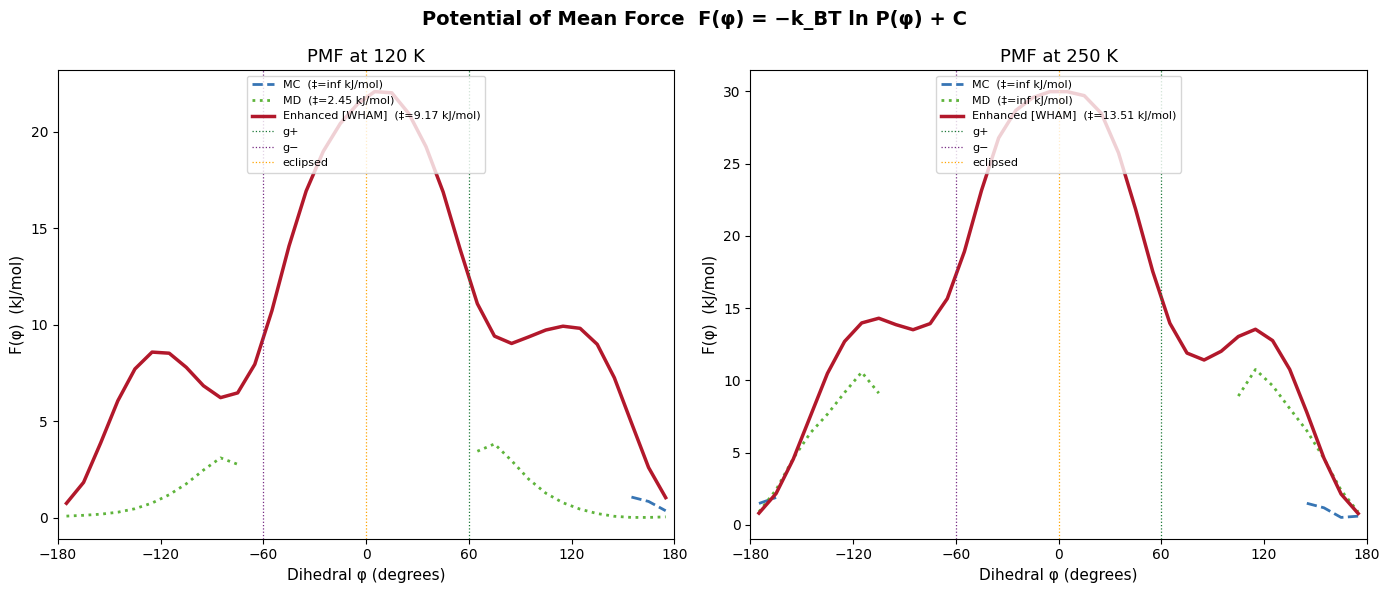

Saved: pmf_comparison.png

Method                 T(K)    ‡ trans→gauche (kJ/mol)   ΔG gauche (kJ/mol)
----------------------------------------------------------------------
  MC                   120                         inf                  inf
  MD                   120                        2.45                 2.75
  WHAM                 120                        9.17                 5.47
  Reference            120                       11.88                 3.26

  MC                   250                         inf                  inf
  MD                   250                         inf                  inf
  WHAM                 250                       13.51                10.62
  Reference            250                       11.88                 3.26



In [121]:
# ─────────────────────────────────────────────────────────────────────────────
# Cell 11 — Task 4b: Potential of Mean Force (PMF) via Boltzmann Inversion
# ─────────────────────────────────────────────────────────────────────────────

import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter1d

import pentane_core as pc
import importlib; importlib.reload(pc)
from pentane_core import (
    kB, J_TO_KJMOL,
    BIN_EDGES, BIN_CENTERS, N_BINS,
    torsion_single,
)

kB_kJ = kB * J_TO_KJMOL  # 8.314e-3 kJ/mol/K

# ── Ensure MC/MD results are available ───────────────────────────────────────

if 'results' not in globals():
    if 'mc_results' in globals() and 'md_results' in globals():
        results = {}
        for T in [120, 250]:
            results[f'MC_{T}'] = {
                'dihedrals' : mc_results[T]['dihedrals'],
                'energies'  : mc_results[T]['energies'],
                'acceptance': mc_results[T].get('acceptance', float('nan')),
            }
            results[f'MD_{T}'] = {
                'dihedrals' : md_results[T]['dihedrals'],
                'energies'  : md_results[T]['energies'],
                'acceptance': md_results[T].get('acceptance', float('nan')),
            }
        print("Rebuilt results from mc_results/md_results.")
    else:
        raise NameError("results not defined. Run MC/MD baseline cells first.")


# ── Unit helpers ──────────────────────────────────────────────────────────────

def _to_rad(d):
    """Convert to radians if values look like degrees (|max| > π + 0.1)."""
    d = np.asarray(d, dtype=float)
    return np.radians(d) if np.abs(d).max() > np.pi + 0.1 else d

def _is_umbrella(er):
    return (len(er.get('centers', [])) == 0 and
            len(er.get('heights',  [])) == 0)


# ── PMF via Boltzmann inversion (always works in radians internally) ──────────

def compute_PMF_rad(dihedrals, T, smooth_sigma=0.0):
    """
    Histogram dihedrals (radians) against core BIN_EDGES, return PMF in kJ/mol.
    Input dihedrals may be in degrees — _to_rad() is applied automatically.
    Returns (bin_centers_rad, pmf_kJmol, probs).
    """
    d = _to_rad(dihedrals)

    counts, _ = np.histogram(d, bins=BIN_EDGES)
    counts = counts.astype(float)
    total  = counts.sum()
    probs  = np.where(counts > 0, counts / total, np.nan)

    if smooth_sigma > 0:
        nan_mask = np.isnan(probs)
        p_tmp    = np.where(nan_mask, 0.0, probs)
        p_smooth = gaussian_filter1d(np.tile(p_tmp, 3), sigma=smooth_sigma)
        probs    = p_smooth[N_BINS : 2 * N_BINS]
        probs    = np.where(nan_mask, np.nan, probs)
        probs    = np.where(probs > 0, probs, np.nan)

    with np.errstate(divide='ignore', invalid='ignore'):
        pmf = -kB_kJ * T * np.log(probs)
    pmf -= np.nanmin(pmf)
    return BIN_CENTERS.copy(), pmf, probs


# ── Reference PMF from torsion scan ──────────────────────────────────────────

def reference_PMF_torsion(T):
    V_kJ = np.array([torsion_single(phi) for phi in BIN_CENTERS]) * J_TO_KJMOL
    V_kJ -= V_kJ.min()
    return BIN_CENTERS.copy(), V_kJ, None


# ── Compute PMFs for all methods ──────────────────────────────────────────────

pmf_data = {}

for T in [120, 250]:
    er = enhanced_results[T]

    # MC and MD — old baseline cells store degrees; _to_rad handles conversion
    pmf_data[f'MC_{T}'] = compute_PMF_rad(
        results[f'MC_{T}']['dihedrals'], T, smooth_sigma=0.8)
    pmf_data[f'MD_{T}'] = compute_PMF_rad(
        results[f'MD_{T}']['dihedrals'], T, smooth_sigma=0.8)

    # Enhanced — umbrella: use WHAM result directly (already radians, kJ/mol)
    if _is_umbrella(er):
        pmf_data[f'Enhanced_{T}'] = (
            er['bin_centers'],  # radians
            er['wham_pmf'],     # kJ/mol, min=0
            er['wham_P'],       # unbiased P
        )
    else:
        # MetaDynamics fallback
        pmf_data[f'Enhanced_{T}'] = compute_PMF_rad(
            er['cold_dihedrals'], T, smooth_sigma=0.8)

    pmf_data[f'Reference_{T}'] = reference_PMF_torsion(T)


# ── Barrier heights ───────────────────────────────────────────────────────────

def barrier_heights(bc_rad, pmf):
    pmf_c = np.where(np.isnan(pmf), np.inf, pmf)
    trans_mask   = np.abs(bc_rad) > np.radians(150)
    gauche_mask  = (np.abs(bc_rad) > np.radians(30))  & (np.abs(bc_rad) < np.radians(90))
    barrier_mask = (np.abs(bc_rad) > np.radians(90))  & (np.abs(bc_rad) < np.radians(150))
    t = np.min(pmf_c[trans_mask])   if trans_mask.any()   else np.nan
    g = np.min(pmf_c[gauche_mask])  if gauche_mask.any()  else np.nan
    b = np.max(pmf_c[barrier_mask]) if barrier_mask.any() else np.nan
    return b - t, g - t


# ── Shared style ──────────────────────────────────────────────────────────────

STYLE = {
    'MC'       : {'color': '#2166ac', 'ls': '--', 'lw': 2.0, 'alpha': 0.9},
    'MD'       : {'color': '#4dac26', 'ls': ':',  'lw': 2.0, 'alpha': 0.9},
    'Enhanced' : {'color': '#b2182b', 'ls': '-',  'lw': 2.5, 'alpha': 1.0},
    'Reference': {'color': 'black',   'ls': '-.', 'lw': 1.5, 'alpha': 0.8},
}

def _smooth_periodic(y, sigma=1.0):
    y = np.asarray(y, dtype=float)
    nan_mask = np.isnan(y)
    p_smooth = gaussian_filter1d(np.tile(np.where(nan_mask, 0.0, y), 3), sigma=sigma)
    return np.where(nan_mask, np.nan, p_smooth[len(y) : 2 * len(y)])


# ── Figure: PMF comparison ────────────────────────────────────────────────────

fig1, axes1 = plt.subplots(1, 2, figsize=(14, 6))
fig1.suptitle("Potential of Mean Force  F(φ) = −k_BT ln P(φ) + C",
              fontsize=14, fontweight='bold')

for col, T in enumerate([120, 250]):
    ax = axes1[col]

    for prefix in ['MC', 'MD', 'Enhanced']:
        bc_rad, pmf_raw, *_ = pmf_data[f'{prefix}_{T}']
        pmf = _smooth_periodic(pmf_raw, sigma=1.0)
        s   = STYLE[prefix]

        if prefix == 'Enhanced':
            tag   = 'WHAM' if _is_umbrella(enhanced_results[T]) else 'MetaD'
            b, g  = barrier_heights(bc_rad, pmf)
            label = f'Enhanced [{tag}]  (‡={b:.2f} kJ/mol)'
        elif prefix == 'Reference':
            label = 'Reference torsion scan'
        else:
            b, g  = barrier_heights(bc_rad, pmf)
            label = f'{prefix}  (‡={b:.2f} kJ/mol)'

        ax.plot(np.degrees(bc_rad), pmf,
                label=label, color=s['color'], ls=s['ls'],
                lw=s['lw'], alpha=s['alpha'])

    for xv, lv, cv in [(60,'g+','#1b7837'), (-60,'g−','#762a83'), (0,'eclipsed','orange')]:
        ax.axvline(xv, color=cv, ls=':', lw=0.9, label=lv)

    ax.set_title(f"PMF at {T} K", fontsize=13)
    ax.set_xlabel("Dihedral φ (degrees)", fontsize=11)
    ax.set_ylabel("F(φ)  (kJ/mol)", fontsize=11)
    ax.set_xlim(-180, 180)
    ax.set_xticks(np.arange(-180, 181, 60))
    ax.legend(fontsize=8, loc='upper center')

plt.tight_layout()
plt.savefig("pmf_comparison.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved: pmf_comparison.png")


# ── Barrier height summary ────────────────────────────────────────────────────

print("\n" + "="*70)
print(f"{'Method':<22} {'T(K)':<6} {'‡ trans→gauche (kJ/mol)':>24} {'ΔG gauche (kJ/mol)':>20}")
print("-"*70)
for T in [120, 250]:
    for prefix in ['MC', 'MD', 'Enhanced', 'Reference']:
        bc_rad, pmf_raw, *_ = pmf_data[f'{prefix}_{T}']
        b, g = barrier_heights(bc_rad, _smooth_periodic(pmf_raw, sigma=1.0))
        tag  = ('WHAM' if (prefix == 'Enhanced' and _is_umbrella(enhanced_results[T]))
                else prefix)
        print(f"  {tag:<20} {T:<6} {b:>24.2f} {g:>20.2f}")